# 09 — Tables de données : membres, tickers, panel annuel

**Objet.** Construire 4 fichiers CSV dans `tables/` :

| fichier | grain | lignes | contenu |
|---|---|---|---|
| `membres.csv` | 1 ligne = 1 membre | 372 | identité, activité, portefeuille, durées, secteurs, risque/perf, track record, comportement |
| `tickers.csv` | 1 ligne = 1 ticker | 4 607 | identité, flux Congrès, marché, après-achats |
| `membres_annees.csv` | 1 ligne = (membre, année) | ~2 600 | activité et performance par année |
| `dictionnaire_colonnes.csv` | 1 ligne = 1 colonne | 145 | définition, section, type de chaque colonne |

Aucune stratégie ici : uniquement de la donnée propre et comprise.

**Comment lire ce document.** Chaque section suit le même schéma :
*définitions → calcul → contrôles → aperçu du tableau → démonstration visuelle sur un membre*
(le membre et le ticker de démonstration se choisissent au §1.2).
Les contrôles sont de 3 types : **recalcul à la main** d'un cas réel, **deuxième méthode**
indépendante (autre implémentation, ou exemple synthétique à réponse connue), **recoupement de
sommes** entre tables (§13). Si un seul contrôle échoue, l'exécution s'arrête : aucun CSV
incohérent ne peut sortir (les fichiers ne sont écrits qu'au §14).

> **Génération 2 (2026-08-11)** — le socle (chargement, prix, reconstruction en parts, mesures)
> est importé du paquet [`tools/membre`](tools/membre/__init__.py), extrait de ce notebook et de
> `copier_les_membres`. La table rejouée est **la table courante du pipeline** : `owner_n`, le
> nom canonique et les commissions (table annexe) viennent du pipeline — plus aucun re-nettoyage
> local. Les validations de ce notebook re-vérifient tout indépendamment ; l'état antérieur
> (adossé à la table v1 du 04/07) reste dans git, et les tables qu'il avait produites sont
> archivées dans `_archive/tables_v20260704/`.

## §0.1 D'où viennent les lignes (l'entonnoir des données)

| étape | lignes | ce qui est écarté et pourquoi |
|---|---|---|
| dépôts uniques collectés (House + Sénat, dépôts 2014-2026) | ~169 000 | — |
| **table nettoyée des transactions** (le point de départ de ce document) | **134 464** | le nettoyage identifie les actions et les ETF (fonds cotés en bourse), retire les doublons purs de re-dépôt, convertit les fourchettes de montant en leur milieu ; options et produits non identifiables écartés |
| fenêtre 2013-2026 | **134 417 trades** | 35 trades datés 2012 ; un dépôt de 2014 peut déclarer une transaction faite fin 2013, d'où une fenêtre qui commence un an avant les dépôts |
| $\mathcal{T}$ : ticker avec un prix exploitable | **118 316 trades** | sans série de prix, aucun rendement n'est calculable ; 3 286 tickers couverts sur 4 607 |

Les deux périmètres sont nommés dans tout le document : $\mathcal{T}^{brut}$ (134 417 trades) et
$\mathcal{T}$ (118 316). **Rien n'est perdu dans les tables** : les 372 membres et 4 607 tickers
de $\mathcal{T}^{brut}$ ont chacun leur ligne ; seules les colonnes qui exigent un prix
(portefeuille, performance) sont calculées sur $\mathcal{T}$, et la colonne `n_trades_brut`
garde la trace du volume complet.

**La chaîne des membres** (chaque compte est vérifié au §1.1) :

$$\underbrace{372}_{\text{tous}} \;\to\; \underbrace{359}_{\ge 1 \text{ trade avec prix}}
\;\to\; \underbrace{266}_{\text{reconstruits}} \;\to\; \underbrace{223}_{\text{éligibles}}$$

- **reconstruit** = on a pu calculer sa série de rendement $r_m$ (au moins 2 jours de
  portefeuille non vide, et une variance non nulle) ;
- **éligible** = assez de matière pour que les statistiques aient un sens :
  $\ge 10$ trades **et** $\ge 126$ jours de bourse actifs (≈ 6 mois). En dessous, une
  volatilité ou un Sharpe annualisés ne veulent rien dire. Ces deux seuils sont des choix de ce
  document, portés par la colonne `eligible` : chacun reste libre de filtrer autrement.

## §0.2 Notations (utilisées dans tout le document)

**Ensembles et indices**

$$m \in \mathcal{M} \;(\text{membres}), \qquad
k \in \mathcal{K} \;(\text{tickers}), \qquad
j \;(\text{trade}), \qquad t \in \mathrm{cal}$$

- Un membre est identifié par son `bioguide_id` : l'identifiant officiel du répertoire
  biographique du Congrès — stable, alors que le nom s'écrit de plusieurs façons selon les dépôts.
- Un ticker est le symbole boursier du titre (ex. AAPL).
- $\mathrm{cal}$ = calendrier de bourse (les jours cotés ; il démarre en 2012 pour disposer
  d'un an de prix avant le premier trade). **252** ≈ le nombre de jours de bourse dans une année :
  toutes les mesures annualisées utilisent $252$ ou $\sqrt{252}$.
- **GICS** = la classification sectorielle standard des marchés (11 secteurs : technologie,
  finance, santé…). NaN = valeur manquante (non calculable).
- **Trade $j$** : $\big(m_j,\; k_j,\; d_j,\; \tau_j,\; \delta_j,\; A_j\big)$ avec
  $d_j \in \{\text{buy}, \text{sell}\}$, $\tau_j$ = date de **transaction** (le jour où le membre
  a réellement acheté/vendu), $\delta_j$ = date de **divulgation** (le jour où le dépôt devient
  public), $A_j$ = montant en dollars (milieu de la fourchette déclarée — la loi n'impose que des
  fourchettes, ex. 1 001-15 000 $).
- **Les deux dates servent à deux choses différentes** : le portefeuille du membre se reconstruit
  à $\tau_j$ (ce qu'il a fait, quand il l'a fait) ; $\delta_j$ mesure la transparence — le délai
  de déclaration $\mathrm{lag}_j = \delta_j - \tau_j$ est étudié au §3.

**Prix et portefeuille reconstruit**

$$P_k(t) = \text{prix ajusté du titre } k, \qquad
n_k^m(t) = \text{nombre de parts de } k \text{ détenues par } m \text{ au jour } t$$

$$V_m(t) = \sum_k n_k^m(t)\,P_k(t) \;(\text{valeur du portefeuille}), \qquad
w_k^m(t) = \frac{n_k^m(t)\,P_k(t)}{V_m(t)} \;(\text{poids du titre } k)$$

$$r_m(t) = \frac{\sum_k n_k^m(t{-}1)\,P_k(t)}{\sum_k n_k^m(t{-}1)\,P_k(t{-}1)} - 1
\;(\text{rendement quotidien du portefeuille})$$

- $r_m$ est dit *time-weighted* : il mesure la qualité des choix, indépendamment de la taille
  des apports d'argent.
- $T_m$ = nombre de jours actifs ($V_m > 0$) ; $r_{SPY}(t)$ = rendement quotidien du SPY (l'ETF
  S&P 500, notre référence de marché) ; $x_j$ = excès de rendement du trade $j$ (défini au §8).

**Limites assumées** : pas d'options ni de produits dérivés (absents de la table) ; montants
connus par fourchettes seulement (le milieu est une approximation).

## §1 Le moteur

Quatre briques, utilisées par toutes les sections :

1. la table des trades, réduite aux colonnes utiles ;
2. les prix ajustés et le calendrier de bourse (l'index du SPY) ;
3. la reconstruction du portefeuille de chaque membre : parts $n_k^m(t)$ (comptabilité FIFO —
   premier lot acheté = premier vendu — et jamais de position négative), valeur $V_m(t)$,
   rendement quotidien $r_m(t)$ ;
4. les fonctions de mesure — Sharpe, information ratio, $\alpha/\beta$ (définies au §7),
   durées de détention (§5), matrice comité $\to$ secteurs (affichée ci-dessous).

Garde-fou prix : les séries manifestement corrompues (prix $< 0{,}10$ \$ ou saut $> 300\,\%$ en
un jour) sont écartées.

In [1]:
# ══ AMORÇAGE — le socle vient de tools/membre (extrait de CE notebook et de copier_les_membres) ══
# Génération 2 : la table COURANTE du pipeline ; conventions membre : tools/membre/__init__.py.
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, ".")
from tools.membre import donnees as mdon, moteur as mmot, mesure as mmes

MCTX = mdon.charger_membre()                     # ⚠️ le §2 nomme M la table des membres — le contexte est MCTX
BASE, PRICES, CLEAN = str(mdon.DOSSIER), str(mdon.PRICES), str(mdon.CLEAN)
df, spy, cal, r_spy = MCTX.df, MCTX.spy, MCTX.cal, MCTX.r_spy
prices, need, missing, corrompus, n0 = MCTX.prices, MCTX.need, MCTX.missing, MCTX.corrompus, MCTX.n0

# les noms historiques du notebook, adossés au contexte
def eff_price(tk, d):      return mmot.eff_price(MCTX, tk, d)
def member_shares(g):      return mmot.member_shares(MCTX, g)
def daily_return(N):       return mmot.daily_return(MCTX, N)
def info_ratio(r):         return mmes.info_ratio(MCTX, r)
def alpha_beta(r):         return mmes.alpha_beta(MCTX, r)
def fifo_holding(g):       return mmot.fifo_holding(MCTX, g)
def exces_spy(bid):        return mmes.exces_spy(MCTX, wf_ret[bid])
stats, sortino = mmes.stats, mmes.sortino
LAST_DAY = cal.max()


134452 -> 134417 trades (fenêtre 2013-2026) | 372 membres | 4,607 tickers
tickers avec prix : 3286 | sans prix : 1260 | corrompus exclus : 61 | trades jetés : 16101 => 118316 exploitables


In [2]:
# — une série de rendement par membre —
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres reconstruits (série de rendement calculable)")

266 membres reconstruits (série de rendement calculable)


In [3]:
# — dfx : la table complète, servie par l'amorçage (owner_n et nom canonique = colonnes pipeline) —
dfx = MCTX.dfx
dfx["disclosure_date"] = pd.to_datetime(dfx["disclosure_date"], errors="coerce")   # δ_j
_name_canon = dfx.groupby("bioguide_id")["name"].agg(lambda s: s.mode().iloc[0])
dfx["name_canon"] = dfx["bioguide_id"].map(_name_canon)
print(f"table complète : {len(dfx)} trades × {dfx.shape[1]} colonnes descriptives | "
      f"owner couvert : {dfx.owner_n.notna().mean():.0%} | {dfx.bioguide_id.nunique()} membres")


table complète : 118316 trades × 41 colonnes descriptives | owner couvert : 100% | 359 membres


In [4]:
# — dfb : la version 𝒯^brut de dfx (AVANT le filtre ticker-avec-prix), servie par l'amorçage —
dfb = MCTX.dfb
print(f"𝒯^brut : {len(dfb)} trades ({MCTX.n0 - len(dfb)} trades hors fenêtre écartés de la table de {MCTX.n0}) | "
      f"{dfb.bioguide_id.nunique()} membres | {dfb.ticker.nunique()} tickers")


𝒯^brut : 134417 trades (35 trades hors fenêtre écartés de la table de 134452) | 372 membres | 4607 tickers


In [5]:
# — km_weighted (propre au §5) ; fifo_holding / exces_spy / sortino viennent de tools.membre —
from collections import deque

def _fifo_holding_reference(g):
    # apparie chaque vente aux achats les plus anciens (FIFO) -> épisodes de détention
    closed, opened = [], []          # (durée_j, parts) fermés ; (durée_censurée_j, parts) ouverts
    for tk, gt in g.groupby("ticker"):
        lots = deque()
        for _, row in gt.sort_values("traded").iterrows():        # même tri que member_shares
            dd, p = eff_price(tk, row["traded"])
            if dd is None: continue
            q = row["size_usd"] / p
            if row["op"] == "buy":
                lots.append([dd, q])
            else:
                held = sum(l[1] for l in lots); qv = min(q, held); take_tot = qv
                while take_tot > 1e-12 and lots:
                    tau_b, parts = lots[0]; take = min(parts, take_tot)
                    closed.append(((dd - tau_b).days, take)); take_tot -= take
                    if parts - take <= 1e-12: lots.popleft()
                    else: lots[0][1] = parts - take
        for tau_b, parts in lots:
            if parts > 1e-9:
                opened.append(((LAST_DAY - tau_b).days, parts))
    return closed, opened

def km_weighted(closed, opened):
    # estimateur de survie de Kaplan-Meier, pondéré par les parts (le pourquoi est au §5)
    ev = pd.DataFrame({"t": closed.duree, "w": closed.parts, "event": 1})
    ce = pd.DataFrame({"t": opened.duree, "w": opened.parts, "event": 0})
    alld = pd.concat([ev, ce]).sort_values("t")
    times = np.sort(ev["t"].unique())
    S = 1.0
    xs, ys = [0], [1.0]
    for t in times:
        at_risk = alld.loc[alld.t >= t, "w"].sum()
        d = ev.loc[ev.t == t, "w"].sum()
        if at_risk > 0:
            S *= (1 - d / at_risk)
        xs.append(t); ys.append(S)
    return np.array(xs), np.array(ys)

def exces_spy(bid):
    # écart de croissance annualisée entre le membre et le SPY, sur la même fenêtre
    r = wf_ret[bid]; nav = (1+r).cumprod(); cagr = nav.iloc[-1]**(252/len(r))-1
    rs = r_spy.reindex(r.index).fillna(0.0); navs = (1+rs).cumprod(); cagrs = navs.iloc[-1]**(252/len(rs))-1
    return cagr - cagrs

def sortino(r):
    # comme le Sharpe, mais seule la volatilité des jours de BAISSE pénalise
    d = r.dropna(); dn = d[d < 0].std()
    return d.mean() / dn * np.sqrt(252) if dn > 0 else np.nan

In [6]:
# — matrice comité → secteurs GICS (d'après la « jurisdiction » officielle de chaque comité) —
SECTEURS = ["Information Technology", "Financials", "Health Care", "Industrials",
            "Consumer Discretionary", "Communication Services", "Consumer Staples",
            "Energy", "Materials", "Real Estate", "Utilities"]

COMITE_GICS = {   # code THOMAS du comité -> secteurs économiques qu'il supervise
    "HSAG": {"Consumer Staples", "Materials"},          "SSAF": {"Consumer Staples", "Materials"},
    "HSAS": {"Industrials"},  "SSAS": {"Industrials"},  "HLIG": {"Industrials"},
    "HSHM": {"Industrials", "Information Technology"},
    "HSBA": {"Financials", "Real Estate"},              "SSBK": {"Financials", "Real Estate"},
    "HSIF": {"Energy", "Utilities", "Health Care", "Communication Services"},
    "HSII": {"Energy", "Materials", "Utilities"},       "SSEG": {"Energy", "Utilities", "Materials"},
    "SSEV": {"Utilities", "Materials", "Industrials"},  "HSPW": {"Industrials", "Utilities"},
    "SSCM": {"Industrials", "Communication Services", "Information Technology"},
    "HSWM": {"Health Care", "Financials"},              "SSFI": {"Health Care", "Financials"},
    "HSSY": {"Information Technology"},                 "SSHR": {"Health Care"},
    "HSVR": {"Health Care"},
    # comités transverses (budget, justice, règlement…) → aucun secteur : les inclure viderait
    # la notion d'« aligné » de son sens
    "HSAP": set(), "SSAP": set(), "HSGO": set(), "SSGA": set(), "HSRU": set(), "HSHA": set(),
    "HSJU": set(), "SSJU": set(), "HSFA": set(), "SSFR": set(), "HSSM": set(), "HSED": set(),
}

import re
def codes_racine(s):
    if not isinstance(s, str):
        return frozenset()
    return frozenset(t.strip()[:4] for t in s.split(";") if re.fullmatch(r"[A-Z]{4}\d*", t.strip()))

**La matrice comité $\to$ secteurs, en clair.** Chaque comité du Congrès a une
« jurisdiction » officielle (les domaines qu'il supervise) ; on la traduit en secteurs GICS.
Les comités transverses (budget, justice, règlement…) ne supervisent aucun secteur en
particulier : ils sont volontairement laissés vides.

In [7]:
_COMITE_NOMS = {
    "HSAG": "House Agriculture",                    "SSAF": "Senate Agriculture, Nutrition & Forestry",
    "HSAS": "House Armed Services",                 "SSAS": "Senate Armed Services",
    "HLIG": "House Intelligence (Select)",          "HSHM": "House Homeland Security",
    "HSBA": "House Financial Services",             "SSBK": "Senate Banking, Housing & Urban Affairs",
    "HSIF": "House Energy & Commerce",              "HSII": "House Natural Resources",
    "SSEG": "Senate Energy & Natural Resources",    "SSEV": "Senate Environment & Public Works",
    "HSPW": "House Transportation & Infrastructure","SSCM": "Senate Commerce, Science & Transportation",
    "HSWM": "House Ways & Means",                   "SSFI": "Senate Finance",
    "HSSY": "House Science, Space & Technology",    "SSHR": "Senate Health, Education, Labor & Pensions",
    "HSVR": "House Veterans' Affairs",
    "HSAP": "House Appropriations",                 "SSAP": "Senate Appropriations",
    "HSGO": "House Oversight",                      "SSGA": "Senate Homeland Security & Gov. Affairs",
    "HSRU": "House Rules",                          "HSHA": "House Administration",
    "HSJU": "House Judiciary",                      "SSJU": "Senate Judiciary",
    "HSFA": "House Foreign Affairs",                "SSFR": "Senate Foreign Relations",
    "HSSM": "House Small Business",                 "HSED": "House Education & Workforce",
}
pd.DataFrame([{"code": c, "comité": _COMITE_NOMS.get(c, "?"),
               "secteurs supervisés": ", ".join(sorted(s)) if s else "— (transverse)"}
              for c, s in COMITE_GICS.items()]).sort_values("code").reset_index(drop=True)

,code,comité,secteurs supervisés
0,HLIG,House Intelligence (Select),Industrials
1,HSAG,House Agriculture,"Consumer Staples, Materials"
2,HSAP,House Appropriations,— (transverse)
3,HSAS,House Armed Services,Industrials
4,HSBA,House Financial Services,"Financials, Real Estate"
5,HSED,House Education & Workforce,— (transverse)
6,HSFA,House Foreign Affairs,— (transverse)
7,HSGO,House Oversight,— (transverse)
8,HSHA,House Administration,— (transverse)
9,HSHM,House Homeland Security,"Industrials, Information Technology"


### §1.1 Contrôles

**Méthodes** : (a) le périmètre = l'entonnoir du §0.1, dérivé de la table elle-même ;
(b) **recalcul à la main** : le portefeuille d'un membre entier est reconstruit par une boucle
naïve, indépendante du moteur — les deux doivent coïncider.

In [8]:
# (a) le périmètre = l'entonnoir du §0.1
assert len(dfb) == 134417 and dfb.bioguide_id.nunique() == 372 and dfb.ticker.nunique() == 4607
assert len(df) == 118316 and len(dfx) == 118316
assert len(need) == 3286
assert df.bioguide_id.nunique() == 359          # membres avec ≥1 trade couvert prix
assert len(wf_ret) == 266                        # reconstruits
_nt = df.groupby("bioguide_id").size()
_nd = pd.Series({b: len(r) for b, r in wf_ret.items()})
_eligible = ((_nt.reindex(_nd.index) >= 10) & (_nd >= 126))
assert int(_eligible.sum()) == 223               # éligibles (définition du §0.1)
print("§1.1 (a) OK — entonnoir vérifié : 134 417 → 118 316 trades ; 372 → 359 → 266 → 223 membres")

§1.1 (a) OK — entonnoir vérifié : 134 417 → 118 316 trades ; 372 → 359 → 266 → 223 membres


In [9]:
# (b) recalcul à la main : un membre entier, reconstruit par une boucle naïve jour par jour
#     r(t) = valeur AUX PRIX DU JOUR des parts détenues LA VEILLE / leur valeur d'hier − 1
_bid_ctl = min(wf_ret, key=lambda b: _nt[b])                 # le plus petit reconstruit (rapide)
_g_ctl = df[df.bioguide_id == _bid_ctl]
_evts = []                                                    # (jour effectif, ticker, parts, sens)
for _, row in _g_ctl.sort_values("traded").iterrows():
    dd, p = eff_price(row["ticker"], row["traded"])
    if dd is None: continue
    _evts.append((dd, row["ticker"], row["size_usd"] / p, row["op"]))
_tks_ctl = sorted({tk for _, tk, _, _ in _evts})
_PX = {tk: prices[tk].values for tk in _tks_ctl}
_parts, _hist = {}, []                                        # parts en fin de chaque jour
for t in cal:
    for dd, tk, q, op in _evts:
        if dd == t:
            h = _parts.get(tk, 0.0)
            _parts[tk] = h + q if op == "buy" else h - min(q, h)      # pas de position négative
    _hist.append(dict(_parts))
_r_vals, _act_vals = [np.nan], []
for i, t in enumerate(cal):
    _act_vals.append(sum(_hist[i].values()) > 0)              # actif = des parts sont détenues
    if i == 0: continue
    _prev = _hist[i - 1]
    _num = sum(q * _PX[tk][i] for tk, q in _prev.items() if np.isfinite(_PX[tk][i]))
    _den = sum(q * _PX[tk][i - 1] for tk, q in _prev.items() if np.isfinite(_PX[tk][i - 1]))
    _r_vals.append(min(max(_num / _den - 1.0, -0.5), 0.5) if _den > 0 else 0.0)
_r_naif = pd.Series(_r_vals, index=cal)
_act = pd.Series(_act_vals, index=cal)
_r_naif = _r_naif.loc[_act.idxmax(): _act[::-1].idxmax()]
_r_moteur = wf_ret[_bid_ctl]
assert _r_naif.index.equals(_r_moteur.index)                  # même fenêtre active
_ecart = (_r_naif.fillna(0) - _r_moteur.fillna(0)).abs().max()
assert _ecart < 1e-9, _ecart
print(f"§1.1 (b) OK — membre {_bid_ctl} ({int(_nt[_bid_ctl])} trades) : boucle naïve = moteur "
      f"(écart max {_ecart:.1e})")

§1.1 (b) OK — membre D000613 (1 trades) : boucle naïve = moteur (écart max 0.0e+00)


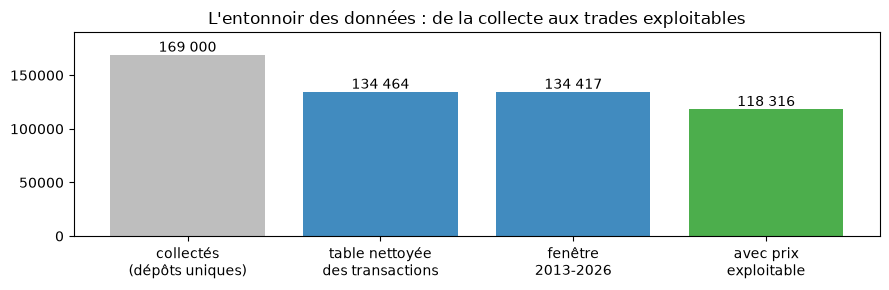

In [10]:
# — figure : l'entonnoir du §0.1 —
fig, ax = plt.subplots(figsize=(9, 3))
_et = [("collectés\n(dépôts uniques)", 169000), ("table nettoyée\ndes transactions", 134464),
       ("fenêtre\n2013-2026", 134417), ("avec prix\nexploitable", 118316)]
_bars = ax.bar([e[0] for e in _et], [e[1] for e in _et],
               color=["0.7", "tab:blue", "tab:blue", "tab:green"], alpha=.85)
for b, (_, v) in zip(_bars, _et):
    ax.text(b.get_x() + b.get_width() / 2, v + 3000, f"{v:,}".replace(",", " "), ha="center", size=10)
ax.set_ylim(0, 190000); ax.set_title("L'entonnoir des données : de la collecte aux trades exploitables")
plt.tight_layout(); plt.show()

## §1.2 La personne (et le ticker) de démonstration

Chaque section est illustrée **sur un membre** avant d'être calculée pour tous.
Pour changer de membre (ou de ticker), il suffit de modifier le nom dans la cellule de
paramètres et de ré-exécuter le document : toutes les démos suivent.

In [11]:
DEMO = "Nancy Pelosi"        # ← change le nom ici (sous-chaîne, insensible à la casse)
TICKER_DEMO = "NVDA"         # ← change le ticker de démo ici (doit avoir un prix)

_hits = dfx.loc[dfx["name_canon"].str.contains(DEMO, case=False, na=False), ["bioguide_id", "name_canon"]].drop_duplicates()
if len(_hits) == 0:
    import difflib
    _prches = difflib.get_close_matches(DEMO, dfx["name_canon"].unique().tolist(), n=5, cutoff=0.3)
    raise ValueError(f"aucun membre ne contient « {DEMO} » — noms proches : {_prches}")
if len(_hits) > 1:
    print("plusieurs membres correspondent, on prend le 1er :", _hits["name_canon"].tolist())
DEMO_BID = _hits["bioguide_id"].iloc[0]
DEMO_NOM = _hits["name_canon"].iloc[0]
assert TICKER_DEMO in need, f"{TICKER_DEMO} n'a pas de prix exploitable"
if DEMO_BID not in wf_ret:
    print(f"⚠ {DEMO_NOM} n'a pas de portefeuille reconstruit — les démos des §4/§5/§7 demanderont un autre membre")
# couleurs constantes des démos : achat vert, vente rouge, membre bleu, SPY gris
C_BUY, C_SELL, C_M, C_SPY = "tab:green", "tab:red", "tab:blue", "0.45"
print(f"démos sur : {DEMO_NOM} ({DEMO_BID}) | ticker : {TICKER_DEMO}")

démos sur : Nancy Pelosi (P000197) | ticker : NVDA


## §2 `membres` — identité et mandat

**But** : qui est chaque membre — parti, chambre, État, mandat, postes de direction, comités, et
les secteurs économiques que ces comités supervisent.

La table `M` démarre : une ligne par membre de $\mathcal{T}^{brut}$ (372 lignes — l'identité ne
dépend pas de la couverture prix). Le « mode » = la valeur la plus fréquente sur ses trades.

$$\texttt{name} = \operatorname{mode}(\text{variantes du nom}), \qquad
\texttt{party},\ \texttt{chamber} = \operatorname{mode}, \qquad
\texttt{state} = \texttt{state\_district}[{:}2]$$

$$\texttt{comites}(m) = \bigcup_j \operatorname{codes}(\texttt{committee\_membership}_j), \qquad
\texttt{secteurs\_juridiction}(m) = \bigcup_{c \in \texttt{comites}(m)} \mathrm{COMITE\_GICS}[c]$$

- `congress_first` / `congress_last` : numéros du premier et du dernier **Congrès** où le membre
  a tradé. Un Congrès est un mandat de 2 ans, numéroté : 113ᵉ = 2013-2014, …, 119ᵉ = 2025-2026.
  Chaque Congrès commence le 3 janvier : un trade du 2 janvier 2013 relève donc encore du 112ᵉ.
- Les comités sont identifiés dans les dépôts par leurs codes officiels (dits « THOMAS », 4
  lettres : HSAG = House Agriculture, SSFI = Senate Finance…) — la table de correspondance
  comité $\to$ secteurs est affichée au §1.
- `years_in_office` : ancienneté (années de mandat) ; avec `leader` et `leader_postes` (l'un des
  12 postes de direction des partis : Speaker, chefs de majorité/minorité, whips…), elle vient de
  deux fichiers de référence vérifiés, joints par `bioguide_id`.
- `comite_cle` : a-t-il siégé dans un comité classé comme influent pour les marchés.

In [12]:
def _mode(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

_ab = dfb.groupby("bioguide_id")
M = pd.DataFrame(index=pd.Index(sorted(dfb.bioguide_id.unique()), name="bioguide_id"))
M["name"] = _ab["name"].agg(_mode)
M.loc[M.index.isin(_name_canon.index), "name"] = _name_canon        # nom canonique prioritaire
M["party"] = _ab["party"].agg(_mode)
M["chamber"] = _ab["chamber"].agg(_mode)
M["state"] = _ab["state_district"].agg(_mode).astype(str).str[:2]
M["congress_first"] = _ab["congress"].min()
M["congress_last"] = _ab["congress"].max()

_anc = pd.read_csv(os.path.join(BASE, "anciennete_2014_2026.csv")).set_index("bioguide_id")["years_in_office"]
M["years_in_office"] = _anc                        # référentiel versionné (extrait daté de table_congres)

_lead = pd.read_csv(os.path.join(BASE, "leadership_2014_2026.csv"))
M["leader"] = M.index.isin(set(_lead["bioguide_id"]))
_postes = _lead.groupby("bioguide_id")["poste"].agg(lambda s: "|".join(sorted(set(s))))
M["leader_postes"] = M.index.map(_postes)

_codes_m = _ab["committee_membership"].agg(lambda s: frozenset().union(*s.map(codes_racine)))
M["comites"] = _codes_m.map(lambda cs: "|".join(sorted(cs)))
M["comite_cle"] = _ab["committees_key_flag"].agg(lambda s: bool(pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any()))
_juri = _codes_m.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
M["secteurs_juridiction"] = _juri.map(lambda ss: "|".join(sorted(ss)))
M["n_secteurs_juridiction"] = _juri.map(len)
print(f"M : {len(M)} membres × {M.shape[1]} colonnes")

M : 372 membres × 13 colonnes


### §2.1 Contrôles

**Méthode** : cohérences internes — clé unique, champs remplis, bornes logiques.

In [13]:
assert len(M) == 372 and M.index.is_unique
assert M["name"].notna().all() and (M["state"].str.len() == 2).all()
assert (M["congress_first"] <= M["congress_last"]).all()
assert M.loc[M["leader"], "leader_postes"].notna().all()            # leader ⇒ poste connu
assert M.loc[~M["leader"], "leader_postes"].isna().all()            # non-leader ⇒ pas de poste
assert (M["n_secteurs_juridiction"] <= 11).all()                    # 11 secteurs GICS au maximum
print(f"§2.1 OK — 372 lignes, clé unique | {int(M.leader.sum())} leaders | "
      f"congrès de {int(M.congress_first.min())} à {int(M.congress_last.max())}")

§2.1 OK — 372 lignes, clé unique | 10 leaders | congrès de 112 à 119


**Aperçu** — les colonnes d'identité, sur les 8 premières lignes (ordre alphabétique des identifiants) :

In [14]:
M[["name", "party", "chamber", "state", "congress_first", "congress_last", "years_in_office",
   "leader", "comites", "secteurs_juridiction"]].head(8)

,name,party,chamber,state,congress_first,congress_last,years_in_office,leader,comites,secteurs_juridiction
bioguide_id,,,,,,,,,,
A000055,Robert B. Aderholt,Republican,house,AL,117,119,28.0,False,,
A000148,Jake Auchincloss,Democrat,house,MA,118,119,5.0,False,,
A000210,Robert E. Andrews,Democrat,house,NJ,113,113,23.0,False,,
A000367,Justin Amash,Republican,house,MI,114,116,9.0,False,,
A000372,Richard W. Allen,Republican,house,GA,115,119,11.0,False,,
A000373,Brad Ashford,Democrat,house,NE,114,114,1.0,False,,
A000378,Cindy Axne,Democrat,house,IA,116,117,3.0,False,,
A000379,Mark Alford,Republican,house,MO,119,119,3.0,False,,


### §2.2 Démo — la carte d'identité du membre choisi

**Lecture :** la ligne de `membres.csv` du membre, mise en page — qui il est, ses comités et les
secteurs que ces comités supervisent.

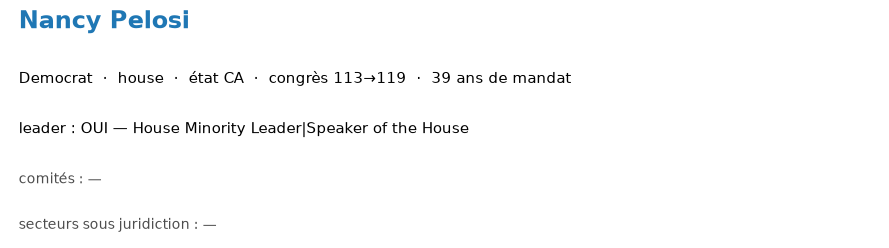

In [15]:
_r = M.loc[DEMO_BID]
fig, ax = plt.subplots(figsize=(9, 2.6)); ax.axis("off")
ax.text(0.01, 0.92, DEMO_NOM, size=17, weight="bold", color=C_M, transform=ax.transAxes)
ax.text(0.01, 0.68, f"{_r['party']}  ·  {_r['chamber']}  ·  état {_r['state']}  ·  "
                    f"congrès {int(_r['congress_first'])}→{int(_r['congress_last'])}  ·  "
                    f"{'' if _r['years_in_office'] != _r['years_in_office'] else str(int(_r['years_in_office'])) + ' ans de mandat'}",
        size=11, transform=ax.transAxes)
ax.text(0.01, 0.46, f"leader : {'OUI — ' + str(_r['leader_postes']) if _r['leader'] else 'non'}",
        size=11, transform=ax.transAxes)
ax.text(0.01, 0.24, f"comités : {_r['comites'] or '—'}", size=10, color="0.3", transform=ax.transAxes)
ax.text(0.01, 0.04, f"secteurs sous juridiction : {_r['secteurs_juridiction'] or '—'}",
        size=10, color="0.3", transform=ax.transAxes)
plt.tight_layout(); plt.show()

## §3 `membres` — activité de déclaration et présence

**But** : comment le membre déclare — volumes, montants, délais de déclaration, qui trade dans le
foyer — et depuis/jusqu'à quand il est « dans le jeu ».

Tout est compté sur $\mathcal{T}$, sauf `n_trades_brut` (compté sur $\mathcal{T}^{brut}$).
Le **notional** = la somme des montants déclarés en dollars (milieux de fourchettes).

$$\texttt{buy\_share} = \frac{\#\{j : d_j = \text{buy}\}}{\#\{j\}}, \qquad
\texttt{notional\_x} = \sum_{j \,:\, d_j = x} A_j, \qquad
\texttt{pct\_1re\_fourchette} = \mathbb{P}\big(A_j \le 8\,000{,}5\big)
\;(8\,000{,}5 = \text{le milieu de la plus petite fourchette légale, } 1\,001\text{-}15\,000\ \$)$$

Le **délai de déclaration** utilise les deux dates du trade
($\mathrm{lag}_j = \delta_j - \tau_j$, en jours ; la loi impose $\le 45$ jours) :

$$\texttt{lag\_med} = \operatorname{med}_j(\mathrm{lag}_j), \qquad
\texttt{part\_late} = \mathbb{P}(\mathrm{lag} > 45\,\text{j}), \qquad
\texttt{part\_very\_late} = \mathbb{P}(\mathrm{lag} > 365\,\text{j})$$

La **présence** (« temps dans le jeu ») :

$$\texttt{first\_trade} = \min_j \tau_j, \qquad \texttt{last\_trade} = \max_j \tau_j, \qquad
\texttt{duree\_activite\_j} = \max_j \tau_j - \min_j \tau_j \;(\text{jours})$$

$$\texttt{actif\_12m} = \mathbb{1}\big\{\max_j \tau_j \ge \max(\mathrm{cal}) - 365\,\text{j}\big\}
\;(\text{a encore tradé dans les 12 derniers mois})$$

`owner_dom` : qui détient le plus souvent le compte (l'élu, son conjoint, un compte joint, un
enfant) ; `part_conjoint` / `part_self` : parts des trades correspondantes.

In [16]:
_ax = dfx.groupby("bioguide_id")
M["n_trades_brut"] = _ab.size()
M["n_trades"] = _ax.size()
M["n_buy"] = _ax["op"].agg(lambda s: int((s == "buy").sum()))
M["n_sell"] = _ax["op"].agg(lambda s: int((s == "sell").sum()))
M["buy_share"] = _ax["op"].agg(lambda s: (s == "buy").mean())
M["notional_total"] = _ax["size_usd"].sum()
M["notional_buy"] = dfx[dfx.op == "buy"].groupby("bioguide_id")["size_usd"].sum()
M["notional_sell"] = dfx[dfx.op == "sell"].groupby("bioguide_id")["size_usd"].sum()
M["taille_med"] = _ax["size_usd"].median()
M["pct_1re_fourchette"] = _ax["size_usd"].agg(lambda s: (s <= 8000.5).mean())
M["lag_med"] = _ax["lag_days"].median()
M["part_late"] = _ax["flag_late_filing"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).mean())
M["part_very_late"] = _ax["flag_very_late_filing"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).mean())
M["owner_dom"] = _ax["owner_n"].agg(_mode)
M["part_conjoint"] = _ax["owner_n"].agg(lambda s: (s == "conjoint").mean())
M["part_self"] = _ax["owner_n"].agg(lambda s: (s == "élu").mean())
M["first_trade"] = _ax["traded"].min().dt.date
M["last_trade"] = _ax["traded"].max().dt.date
M["duree_activite_j"] = (_ax["traded"].max() - _ax["traded"].min()).dt.days
M["n_annees_actives"] = _ax["traded"].agg(lambda s: s.dt.year.nunique())
M["actif_12m"] = _ax["traded"].max() >= (cal.max() - pd.Timedelta(days=365))
print(f"M : {M.shape[1]} colonnes après le §3")

M : 34 colonnes après le §3


### §3.1 Contrôles

**Méthodes** : recoupements de sommes (les totaux par membre doivent redonner les totaux de la
table) + recalcul à la main d'un membre (comptage direct, ligne à ligne).

In [17]:
# recoupements de sommes
assert int(M["n_trades_brut"].sum()) == 134417
assert int(M["n_trades"].fillna(0).sum()) == 118316
assert int((M["n_buy"].fillna(0) + M["n_sell"].fillna(0)).sum()) == 118316
assert abs(M["notional_total"].fillna(0).sum() - dfx["size_usd"].sum()) < 0.01
assert pd.Timestamp(M["first_trade"].dropna().min()) == df["traded"].min()
# recalcul à la main : le membre le plus actif, compté directement
_b0 = M["n_trades"].idxmax()
_sub = dfx[dfx.bioguide_id == _b0]
assert int(M.loc[_b0, "n_trades"]) == len(_sub)
assert abs(M.loc[_b0, "buy_share"] - (_sub["op"] == "buy").sum() / len(_sub)) < 1e-12
assert M.loc[_b0, "first_trade"] == _sub["traded"].min().date()
assert abs(M.loc[_b0, "lag_med"] - _sub["lag_days"].median()) < 1e-12
print(f"§3.1 OK — sommes exactes | recalcul direct identique sur {M.loc[_b0, 'name']} "
      f"| membres actifs sur les 12 derniers mois : {int(M.actif_12m.sum())}")

§3.1 OK — sommes exactes | recalcul direct identique sur Rohit Khanna | membres actifs sur les 12 derniers mois : 103


**Aperçu** — les colonnes d'activité, sur les 8 membres qui ont le plus de trades :

In [18]:
(M.sort_values("n_trades", ascending=False)
  [["name", "n_trades", "n_buy", "n_sell", "buy_share", "notional_total", "taille_med",
    "lag_med", "first_trade", "last_trade", "duree_activite_j", "actif_12m"]]
  .head(8).round(3))

,name,n_trades,n_buy,n_sell,buy_share,notional_total,taille_med,lag_med,first_trade,last_trade,duree_activite_j,actif_12m
bioguide_id,,,,,,,,,,,,
K000389,Rohit Khanna,32730.0,18492.0,14238.0,0.565,521215864.5,8000.5,25.0,2017-01-05,2026-05-28,3430.0,True
M001157,Michael T. McCaul,16139.0,7377.0,8762.0,0.457,787372584.5,8000.5,35.0,2013-12-03,2026-05-29,4560.0,True
R000586,James B. Renacci,3988.0,2154.0,1834.0,0.540,77070994.0,8000.5,14.0,2013-12-30,2018-12-12,1808.0,False
G000583,Josh Gottheimer,3055.0,1257.0,1798.0,0.411,33522027.5,8000.5,28.0,2017-01-03,2026-05-27,3431.0,True
R000582,David P. Roe,3004.0,1276.0,1728.0,0.425,42546502.0,8000.5,29.0,2013-12-09,2020-11-30,2548.0,False
M001193,Thomas MacArthur,2629.0,1393.0,1236.0,0.530,89968814.5,8000.5,26.0,2015-01-06,2018-12-31,1455.0,False
H001086,Diana Harshbarger,2577.0,1015.0,1562.0,0.394,380158468.5,8000.5,36.0,2021-01-04,2023-02-16,773.0,False
C001123,Gilbert Cisneros,2288.0,1334.0,954.0,0.583,24793644.0,8000.5,27.0,2019-01-18,2026-06-30,2720.0,True


### §3.2 Démo — toute son activité en une figure

**Lecture :** en haut, chaque point est un trade (abscisse = date de transaction $\tau_j$,
ordonnée = montant $A_j$ en échelle log, vert = achat, rouge = vente) ; en bas, le nombre de
trades par année. On voit d'un coup d'œil depuis quand il trade, à quel rythme, et ses montants.

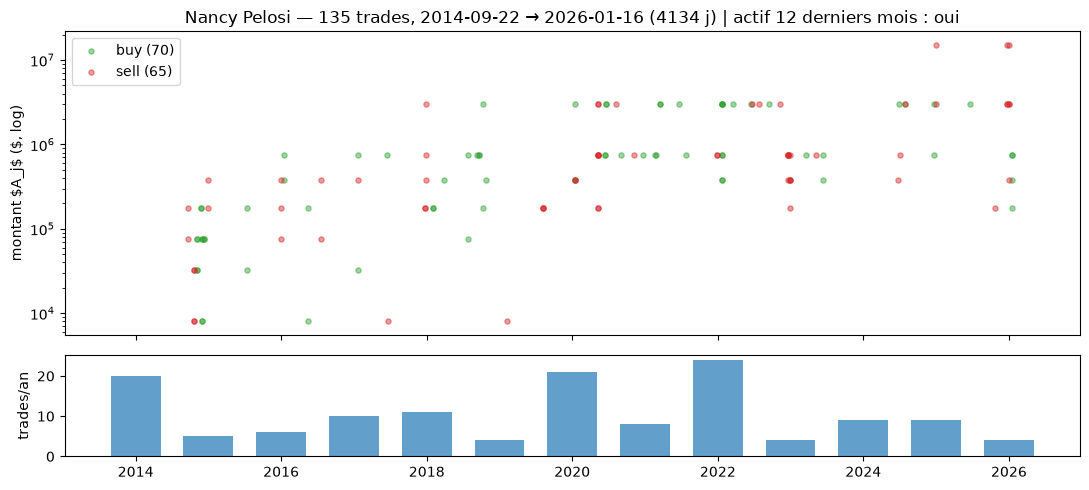

part d'achats 52% | taille médiane 750,000 $ | délai médian de déclaration 26 j | compte dominant : conjoint


In [19]:
_g = dfx[dfx.bioguide_id == DEMO_BID]
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
for _dop, _dc in [("buy", C_BUY), ("sell", C_SELL)]:
    _ds = _g[_g.op == _dop]
    ax[0].scatter(_ds["traded"], _ds["size_usd"], s=14, alpha=.45, color=_dc,
                  label=f"{_dop} ({len(_ds):,})")
ax[0].set_yscale("log"); ax[0].set_ylabel("montant $A_j$ ($, log)"); ax[0].legend(loc="upper left")
_r = M.loc[DEMO_BID]
ax[0].set_title(f"{DEMO_NOM} — {int(_r['n_trades'])} trades, {str(_r['first_trade'])} → {str(_r['last_trade'])} "
                f"({int(_r['duree_activite_j'])} j) | actif 12 derniers mois : {'oui' if _r['actif_12m'] else 'non'}")
_par_an = _g.groupby(_g["traded"].dt.year).size()
ax[1].bar(pd.to_datetime(_par_an.index, format="%Y"), _par_an.values, width=250, color=C_M, alpha=.7)
ax[1].set_ylabel("trades/an")
plt.tight_layout(); plt.show()
print(f"part d'achats {_r['buy_share']:.0%} | taille médiane {_r['taille_med']:,.0f} $ | "
      f"délai médian de déclaration {_r['lag_med']:.0f} j | compte dominant : {_r['owner_dom']}")

## §4 `membres` — portefeuille : valeur et concentration

**But** : à quoi ressemble le portefeuille reconstruit de chaque membre — sa taille, sa
concentration, sa rotation.

Les mesures (moyennes prises sur les jours actifs, $V_m > 0$) :

- **HHI** (indice de Herfindahl) = concentration du portefeuille : la somme des carrés des poids.
  Vaut 1 si tout est sur un seul titre, $1/N$ si $N$ titres à poids égaux.
- **N_eff** $= 1/\mathrm{HHI}$ : le nombre *équivalent* de lignes équipondérées — « ce portefeuille
  se comporte comme N_eff titres à poids égaux ».
- **top1** : le poids moyen de la plus grosse ligne.
- **turnover** : la rotation — combien de fois le portefeuille « tourne » par an
  (flux échangé rapporté à la taille moyenne).

$$\mathrm{HHI}_m = \overline{\Big(\sum_k w_k^m(t)^2\Big)}, \qquad
N^{e\!f\!f}_m = \frac{1}{\mathrm{HHI}_m}, \qquad
\texttt{top1}_m = \overline{\max_k w_k^m(t)}, \qquad
\texttt{turnover}_m = \frac{\sum_j A_j}{2\,\bar V_m} \cdot \frac{252}{T_m}$$

Les **épisodes de détention** (un achat apparié à sa revente, FIFO) sont aussi construits ici,
membre par membre : ils servent au §5.

In [20]:
PORT, EPIS = {}, {}
for b in wf_ret:
    g = df[df.bioguide_id == b]
    N = member_shares(g)
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    NP = N * P
    V = NP.sum(axis=1); act = V > 0
    W = NP.div(V, axis=0)[act]
    hhi = float((W ** 2).sum(axis=1).mean())
    vbar = float(V[act].mean())
    PORT[b] = dict(
        hhi=hhi, n_eff=1 / hhi if hhi > 0 else np.nan,
        top1=float(W.max(axis=1).mean()),
        n_pos_moy=float((N[act] > 0).sum(axis=1).mean()),
        valeur_moy=vbar, valeur_fin=float(V.iloc[-1]),
        turnover=(g["size_usd"].sum() / (2 * vbar) * 252 / int(act.sum()))
                 if (vbar > 0 and act.sum() >= 2) else np.nan)
    EPIS[b] = fifo_holding(g)
    del N, P, NP, V, W
_port = pd.DataFrame(PORT).T
for c in _port.columns:
    M[c] = _port[c]
M["reconstruit"] = M.index.isin(wf_ret)
M["n_days"] = pd.Series({b: len(r) for b, r in wf_ret.items()})
M["n_tickers"] = dfx.groupby("bioguide_id")["ticker"].nunique()
M["n_episodes_fermes"] = pd.Series({b: len(c) for b, (c, o) in EPIS.items()})
print(f"{len(PORT)} membres | colonnes de portefeuille jointes à M")

266 membres | colonnes de portefeuille jointes à M


### §4.1 Contrôles

**Méthodes** : (i) deuxième méthode — la concentration est recalculée par une fonction écrite
séparément, sur 3 membres (identité exigée) ; (ii) conservation — les parts encore ouvertes selon
l'appariement FIFO doivent égaler les parts finales de la reconstruction, membre par membre.

In [21]:
# (i) deuxième méthode : concentration recalculée indépendamment sur 3 membres
def concentration(bid):                                 # fonction de contrôle, écrite séparément
    g = df[df.bioguide_id == bid]; N = member_shares(g)
    if N is None: return None
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    V = (N*P).sum(axis=1); act = V > 0
    if act.sum() == 0: return None
    W = (N*P).div(V, axis=0)[act]
    hhi = (W**2).sum(axis=1).mean()
    return dict(hhi=hhi, n_eff=1/hhi if hhi>0 else np.nan, top1=W.max(axis=1).mean(),
                n_pos_moy=(N[act]>0).sum(axis=1).mean())
_ctl3 = list(M[M.reconstruit].sort_values("n_trades", ascending=False).index[:2]) + \
        [M[M.reconstruit].sort_values("n_trades").index[0]]           # 2 gros + 1 petit
for _b in _ctl3:
    _ref = concentration(_b)
    for _k in ("hhi", "n_eff", "top1", "n_pos_moy"):
        assert abs(_ref[_k] - M.loc[_b, _k]) < 1e-9, (_b, _k)

# (ii) conservation FIFO ↔ reconstruction : parts encore ouvertes = parts finales, sur 20 membres
_ctl20 = list(wf_ret)[::max(1, len(wf_ret) // 20)][:20]
for _b in _ctl20:
    _ouvert_fifo = sum(p for _, p in EPIS[_b][1])
    _final_rec = float(member_shares(df[df.bioguide_id == _b]).iloc[-1].sum())
    assert abs(_ouvert_fifo - _final_rec) < 1e-6 * max(1.0, _final_rec), _b
print(f"§4.1 OK — concentration : 2e méthode identique sur {len(_ctl3)} membres | "
      f"conservation FIFO exacte sur {len(_ctl20)} membres")

§4.1 OK — concentration : 2e méthode identique sur 3 membres | conservation FIFO exacte sur 20 membres


**Aperçu** — les colonnes de portefeuille, sur les 8 plus gros portefeuilles (valeur moyenne) :

In [22]:
(M[M.reconstruit].sort_values("valeur_moy", ascending=False)
  [["name", "n_days", "n_tickers", "valeur_moy", "hhi", "n_eff", "top1", "n_pos_moy",
    "turnover", "n_episodes_fermes"]]
  .head(8).round(3))

,name,n_days,n_tickers,valeur_moy,hhi,n_eff,top1,n_pos_moy,turnover,n_episodes_fermes
bioguide_id,,,,,,,,,,
H001086,Diana Harshbarger,1380.0,174.0,1.474543e+08,0.044,22.860,0.099,96.614,0.235,943.0
M001157,Michael T. McCaul,3163.0,582.0,1.428981e+08,0.081,12.358,0.175,185.392,0.219,9891.0
K000389,Rohit Khanna,2373.0,976.0,9.394363e+07,0.007,141.767,0.033,582.610,0.295,22560.0
A000373,Brad Ashford,2853.0,15.0,7.029621e+07,0.991,1.010,0.995,6.549,0.024,6.0
C001035,Susan M Collins,3146.0,179.0,4.234744e+07,0.828,1.207,0.890,57.556,0.039,69.0
F000062,DIANNE FEINSTEIN,2152.0,52.0,4.063682e+07,0.056,17.819,0.112,29.637,0.163,241.0
R000586,James B. Renacci,3145.0,557.0,2.924570e+07,0.011,93.359,0.035,297.929,0.106,2005.0
P000197,Nancy Pelosi,2914.0,33.0,2.884926e+07,0.335,2.985,0.430,9.638,0.266,54.0


### §4.2 Démo — son portefeuille reconstruit dans le temps

**Lecture :** en haut, la valeur $V_m(t)$ du portefeuille (échelle log) ; en bas, les poids
$w_k^m(t)$ de ses 8 plus grosses positions empilés (le reste en « autres ») — on voit la
concentration et ses changements.

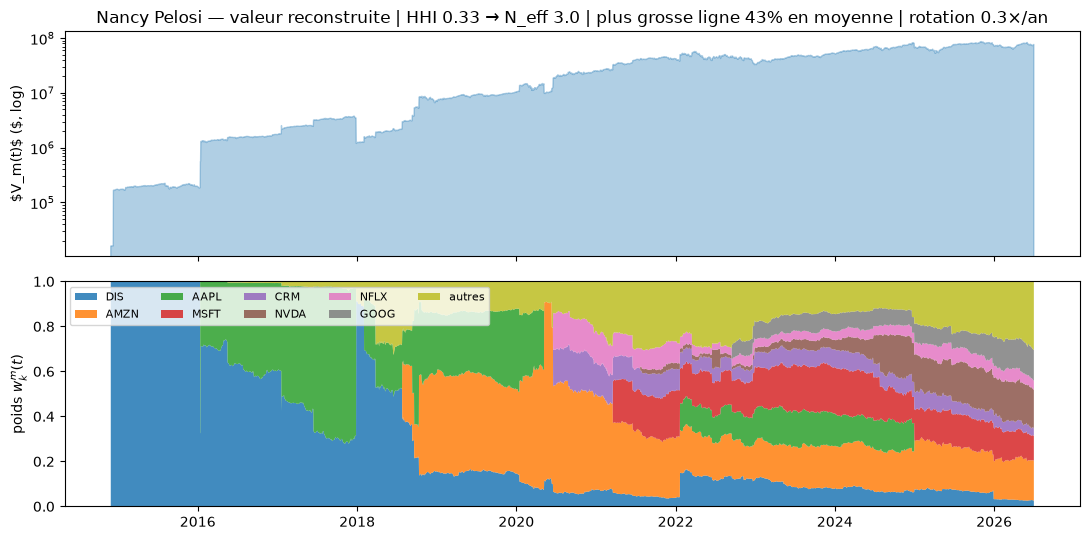

In [23]:
assert DEMO_BID in wf_ret, "membre non reconstruit : choisis-en un autre au §1.2"
_N = member_shares(df[df.bioguide_id == DEMO_BID])
_P = pd.DataFrame({tk: prices[tk] for tk in _N.columns})
_V = (_N * _P).sum(axis=1); _act = _V > 0
_W = (_N * _P).div(_V, axis=0)[_act]
_top8 = _W.mean().sort_values(ascending=False).head(8).index
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax[0].fill_between(_V[_act].index, _V[_act].values, color=C_M, alpha=.35)
ax[0].set_yscale("log"); ax[0].set_ylabel("$V_m(t)$ ($, log)")
_r = M.loc[DEMO_BID]
ax[0].set_title(f"{DEMO_NOM} — valeur reconstruite | HHI {_r['hhi']:.2f} → N_eff {_r['n_eff']:.1f} | "
                f"plus grosse ligne {_r['top1']:.0%} en moyenne | rotation {_r['turnover']:.1f}×/an")
_Wp = _W[_top8].clip(lower=0)
_Wp["autres"] = (1 - _Wp.sum(axis=1)).clip(lower=0)
ax[1].stackplot(_Wp.index, [_Wp[c].values for c in _Wp.columns], labels=list(_Wp.columns), alpha=.85)
ax[1].set_ylim(0, 1); ax[1].set_ylabel("poids $w_k^m(t)$"); ax[1].legend(ncol=5, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()
del _N, _P, _V, _W, _Wp

## §5 `membres` — durées de détention

**But** : combien de temps chaque membre garde ses positions.

Le problème : au dernier jour des données, **une grande partie des parts n'a jamais été
revendue** — leur durée finale est inconnue (on dit *censurée*). Faire la moyenne des seules
positions revendues sous-estimerait les durées (les positions longues sont justement celles qui
ne sont pas encore closes). L'**estimateur de Kaplan-Meier** — l'outil standard des durées de vie
en médecine — utilise les deux : positions closes *et* positions encore ouvertes.

$$\texttt{duree\_med\_fermee}_m = \operatorname{med}_{parts}(\text{durées des épisodes clos}), \qquad
\texttt{duree\_km\_med}_m = \inf\{t : \hat S_m(t) \le 0{,}5\}$$

$$\texttt{part\_ouverte}_m = \frac{\sum_{ouverts} q}{\sum_{clos} q + \sum_{ouverts} q}, \qquad
\texttt{n\_allers\_retours\_30j}_m = \#\{\text{épisodes clos} < 30 \text{ j}\}$$

$\hat S_m(t)$ = probabilité qu'une part achetée soit encore détenue $t$ jours plus tard.
`duree_km_med` = NaN quand plus de 50 % des parts ne sont jamais revendues : la « durée médiane »
n'existe pas pour un buy-and-holder — ce NaN est une information en soi, à lire avec
`part_ouverte`.

In [24]:
def _med_ponderee(d, w):
    # médiane pondérée : première durée (triée) dont le cumul des poids atteint 50 %
    o = np.argsort(d); d, w = np.asarray(d)[o], np.asarray(w)[o]
    cw = np.cumsum(w)
    return float(d[np.searchsorted(cw, 0.5 * cw[-1])])

_rows = {}
for b, (c, o) in EPIS.items():
    cl = pd.DataFrame(c, columns=["duree", "parts"]); op = pd.DataFrame(o, columns=["duree", "parts"])
    row = dict(part_ouverte=op.parts.sum() / (cl.parts.sum() + op.parts.sum())
               if (cl.parts.sum() + op.parts.sum()) > 0 else np.nan,
               n_allers_retours_30j=int((cl.duree < 30).sum()))
    row["duree_med_fermee"] = _med_ponderee(cl.duree.values, cl.parts.values) if len(cl) else np.nan
    if len(cl):
        kx, ky = km_weighted(cl, op)
        row["duree_km_med"] = float(kx[np.searchsorted(-ky, -0.5)]) if ky.min() <= 0.5 else np.nan
    else:
        row["duree_km_med"] = np.nan
    _rows[b] = row
_dur = pd.DataFrame(_rows).T
for c in _dur.columns:
    M[c] = _dur[c]
print(f"durées : {len(_dur)} membres | médiane KM atteinte pour {int(M.duree_km_med.notna().sum())} membres "
      f"(NaN = plus de 50 % des parts jamais revendues)")

durées : 266 membres | médiane KM atteinte pour 125 membres (NaN = plus de 50 % des parts jamais revendues)


### §5.1 Contrôles

**Méthodes** : (i) exemple synthétique à réponse connue (médiane pondérée et Kaplan-Meier) ;
(ii) recoupement — la part encore détenue calculée globalement doit égaler la ré-agrégation des
chiffres par membre.

In [25]:
# (i) exemple synthétique : 2 épisodes clos (10 j, poids 1) et (100 j, poids 1), 0 ouvert
#     -> médiane pondérée = 10 (le cumul atteint 50 % au 1er) ; KM : S(10)=0,5 -> médiane = 10
_clt = pd.DataFrame({"duree": [10, 100], "parts": [1.0, 1.0]})
_opt = pd.DataFrame({"duree": [], "parts": []})
assert _med_ponderee(_clt.duree.values, _clt.parts.values) == 10
_kxt, _kyt = km_weighted(_clt, _opt)
assert float(_kxt[np.searchsorted(-_kyt, -0.5)]) == 10.0

# (ii) recoupement global ↔ par membre (et courbe de survie tous membres, pour la démo)
_cl = pd.DataFrame([e for c, o in EPIS.values() for e in c], columns=["duree", "parts"])
_op = pd.DataFrame([e for c, o in EPIS.values() for e in o], columns=["duree", "parts"])
_pool_direct = _op.parts.sum() / (_cl.parts.sum() + _op.parts.sum())
_tot_cl = sum(pd.DataFrame(c, columns=["duree", "parts"]).parts.sum() for c, o in EPIS.values())
_tot_op = sum(pd.DataFrame(o, columns=["duree", "parts"]).parts.sum() for c, o in EPIS.values())
assert abs(_pool_direct - _tot_op / (_tot_cl + _tot_op)) < 1e-12
_kx, _ky = km_weighted(_cl, _op)
_med_km_pool = _kx[np.searchsorted(-_ky, -0.5)] if _ky.min() <= 0.5 else np.nan
print(f"§5.1 OK — synthétique exact | {len(_cl):,} épisodes clos, {len(_op):,} encore ouverts | "
      f"part encore détenue {_pool_direct:.0%} (pondérée par les PARTS, pas par le nombre d'épisodes) | "
      f"médiane de survie tous membres {_med_km_pool:.0f} j")

§5.1 OK — synthétique exact | 62,135 épisodes clos, 29,051 encore ouverts | part encore détenue 44% (pondérée par les PARTS, pas par le nombre d'épisodes) | médiane de survie tous membres 960 j


**Aperçu** — les colonnes de durées, sur les 8 membres aux épisodes de détention les plus nombreux :

In [26]:
(M.sort_values("n_episodes_fermes", ascending=False)
  [["name", "n_episodes_fermes", "duree_med_fermee", "duree_km_med", "part_ouverte",
    "n_allers_retours_30j"]]
  .head(8).round(3))

,name,n_episodes_fermes,duree_med_fermee,duree_km_med,part_ouverte,n_allers_retours_30j
bioguide_id,,,,,,
K000389,Rohit Khanna,22560.0,435.0,1031.0,0.436,572.0
M001157,Michael T. McCaul,9891.0,503.0,1134.0,0.417,530.0
R000586,James B. Renacci,2005.0,288.0,618.0,0.404,93.0
G000583,Josh Gottheimer,1745.0,393.0,549.0,0.229,45.0
R000582,David P. Roe,1707.0,206.0,304.0,0.227,138.0
M001193,Thomas MacArthur,1305.0,161.0,308.0,0.322,168.0
P000612,"David A Perdue , Jr",1265.0,389.0,504.0,0.185,48.0
H001086,Diana Harshbarger,943.0,277.0,NaN,0.819,188.0


### §5.2 Démo — combien de temps garde-t-il ses positions ?

**Lecture :** la courbe donne, pour chaque durée $t$ (abscisse), la probabilité qu'une part
achetée soit **encore détenue** $t$ jours plus tard. Elle part de 1 et descend à chaque revente ;
là où elle croise 0,5 se trouve la durée médiane. Bleu = le membre, gris = tous les membres.

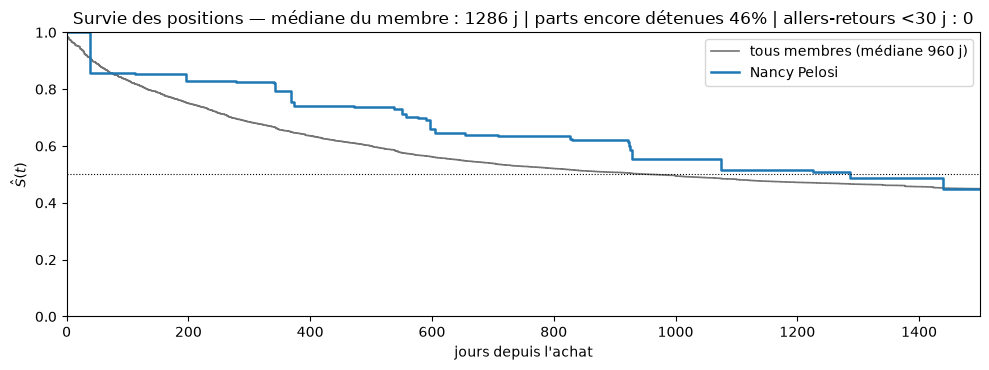

In [27]:
assert DEMO_BID in wf_ret, "membre non reconstruit : choisis-en un autre au §1.2"
_cE, _oE = EPIS[DEMO_BID]
_cld = pd.DataFrame(_cE, columns=["duree", "parts"]); _opd = pd.DataFrame(_oE, columns=["duree", "parts"])
_kxm, _kym = km_weighted(_cld, _opd)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.step(_kx, _ky, where="post", color=C_SPY, lw=1.2,
        label=f"tous membres (médiane {_med_km_pool:.0f} j)")
ax.step(_kxm, _kym, where="post", color=C_M, lw=1.8, label=DEMO_NOM)
ax.axhline(0.5, color="k", ls=":", lw=0.8)
_r = M.loc[DEMO_BID]
_med_txt = f"{_r['duree_km_med']:.0f} j" if _r['duree_km_med'] == _r['duree_km_med'] else "non atteinte (>50 % encore détenu)"
ax.set_title(f"Survie des positions — médiane du membre : {_med_txt} | "
             f"parts encore détenues {_r['part_ouverte']:.0%} | allers-retours <30 j : {int(_r['n_allers_retours_30j'])}")
ax.set_xlabel("jours depuis l'achat"); ax.set_ylabel("$\\hat S(t)$"); ax.set_ylim(0, 1); ax.set_xlim(0, 1500); ax.legend()
plt.tight_layout(); plt.show()

## §6 `membres` — actions principales et secteurs

**But** : quelles actions et quels secteurs dominent les achats de chaque membre.

Tout est mesuré en part du **notional d'achat** (les montants déclarés, pas les poids
quotidiens — c'est vérifiable directement dans la table) :

$$\texttt{topK\_part}_m = \frac{\sum_{j\,:\,k_j = \text{topK},\, d_j = \text{buy}} A_j}{\texttt{notional\_buy}_m},
\qquad
\texttt{sect\_s}_m = \frac{\sum_{j\,:\,\mathrm{GICS}(k_j) = s,\, d_j = \text{buy}} A_j}{\texttt{notional\_buy}_m},
\qquad \sum_s \texttt{sect\_s}_m = 1$$

`sect_nc` recueille les achats sans secteur GICS connu, pour que la somme fasse toujours 1.

In [28]:
_buys = dfx[dfx.op == "buy"]
_mk = _buys.groupby(["bioguide_id", "ticker"])["size_usd"].sum().sort_values(ascending=False)
_top = (_mk.groupby(level=0).head(10).reset_index()
        .sort_values(["bioguide_id", "size_usd"], ascending=[True, False]))
_tl = _top.groupby("bioguide_id").agg(tks=("ticker", list), usd=("size_usd", list))
for i in (1, 2, 3):
    M[f"top{i}_ticker"] = _tl["tks"].map(lambda l: l[i - 1] if len(l) >= i else np.nan)
    M[f"top{i}_part"] = _tl["usd"].map(lambda l: l[i - 1] if len(l) >= i else np.nan) / M["notional_buy"]
M["top10_tickers"] = _tl["tks"].map("|".join)

SECT_COLS = {"Information Technology": "sect_info_tech", "Financials": "sect_financials",
             "Health Care": "sect_health", "Industrials": "sect_industrials",
             "Consumer Discretionary": "sect_conso_disc", "Communication Services": "sect_comm",
             "Consumer Staples": "sect_conso_stap", "Energy": "sect_energy",
             "Materials": "sect_materials", "Real Estate": "sect_real_estate",
             "Utilities": "sect_utilities"}
_sec = (_buys.assign(sg=_buys["sector_gics"].map(SECT_COLS).fillna("sect_nc"))
        .pivot_table(index="bioguide_id", columns="sg", values="size_usd", aggfunc="sum", fill_value=0.0))
for c in list(SECT_COLS.values()) + ["sect_nc"]:
    if c not in _sec.columns:
        _sec[c] = 0.0
_sec = _sec.div(_sec.sum(axis=1), axis=0)
for c in list(SECT_COLS.values()) + ["sect_nc"]:
    M[c] = _sec[c]
M["sect_dom"] = _buys.groupby("bioguide_id")["sector_gics"].agg(_mode)
_sd = _sec[list(SECT_COLS.values()) + ["sect_nc"]].max(axis=1)
M["part_sect_dom"] = _sd
print(f"top tickers + 12 parts sectorielles pour {int(M.top1_ticker.notna().sum())} membres "
      f"(ceux qui ont au moins un ACHAT dans 𝒯 — les autres n'ont que des ventes)")

top tickers + 12 parts sectorielles pour 268 membres (ceux qui ont au moins un ACHAT dans 𝒯 — les autres n'ont que des ventes)


### §6.1 Contrôles

**Méthodes** : cohérences internes (les 12 parts somment à 1 ; le top 1 pèse au moins autant que
le top 2) + recalcul à la main du plus gros acheteur.

In [29]:
_sc = list(SECT_COLS.values()) + ["sect_nc"]
_has_buy = M["notional_buy"].fillna(0) > 0
_sums = M.loc[_has_buy, _sc].sum(axis=1)
assert (abs(_sums - 1) < 1e-9).all(), "les 12 parts sectorielles doivent sommer à 1"
assert (M.loc[_has_buy, "top1_part"] >= M.loc[_has_buy, "top2_part"].fillna(0)).all()
# recalcul à la main : le plus gros acheteur, compté directement dans la table
# (comparaison en $, pas en nom : deux tickers peuvent être ex æquo au sommet)
_bA = M["notional_buy"].idxmax()
_subA = _buys[_buys.bioguide_id == _bA].groupby("ticker")["size_usd"].sum().sort_values(ascending=False)
assert abs(_subA.loc[M.loc[_bA, "top1_ticker"]] - _subA.iloc[0]) < 1e-9
assert abs(M.loc[_bA, "top1_part"] - _subA.iloc[0] / _subA.sum()) < 1e-12
print(f"§6.1 OK — Σ parts = 1 partout | recalcul direct identique sur {M.loc[_bA, 'name']} "
      f"(top 1 : {M.loc[_bA, 'top1_ticker']}, {M.loc[_bA, 'top1_part']:.0%} de ses achats)")

§6.1 OK — Σ parts = 1 partout | recalcul direct identique sur Michael T. McCaul (top 1 : LAZ, 5% de ses achats)


**Aperçu** — actions principales et secteurs, sur les 8 plus gros acheteurs (notional d'achat) :

In [30]:
(M.sort_values("notional_buy", ascending=False)
  [["name", "top1_ticker", "top1_part", "top2_ticker", "top3_ticker", "top10_tickers",
    "sect_dom", "part_sect_dom"]]
  .head(8).round(3))

,name,top1_ticker,top1_part,top2_ticker,top3_ticker,top10_tickers,sect_dom,part_sect_dom
bioguide_id,,,,,,,,
M001157,Michael T. McCaul,LAZ,0.054,EFA,VEA,LAZ|EFA|VEA|VTI|VOO|VDE|IEMG|QQQ|META|IEFA,Financials,0.237
K000389,Rohit Khanna,GOOGL,0.011,MU,META,GOOGL|MU|META|AMZN|MSFT|DIS|V|CAT|AAPL|BAC,Information Technology,0.168
H001086,Diana Harshbarger,GEN,0.062,CHGG,AMZN,GEN|CHGG|AMZN|EA|ORCL|WTW|AVGO|GNRC|ADBE|NOW,Information Technology,0.288
P000197,Nancy Pelosi,AAPL,0.157,NVDA,AMZN,AAPL|NVDA|AMZN|DIS|MSFT|GOOGL|PYPL|NFLX|TSLA|AVGO,Information Technology,0.526
D000617,Suzan K. DelBene,MSFT,0.983,SPWR,WTS,MSFT|SPWR|WTS|WMS|XYL|HASI|CSIQ|CAFD|BIOA|ERII,Information Technology,0.989
F000062,DIANNE FEINSTEIN,CHTR,0.053,MCHP,A,CHTR|MCHP|A|CURI|JPM|BA|CCI|SBUX|BAM|TFX,Information Technology,0.180
M001193,Thomas MacArthur,VEA,0.104,IEMG,EFA,VEA|IEMG|EFA|XLF|VIG|IWD|IWF|ACN|VWO|SCHD,Information Technology,0.482
G000584,Greg Gianforte,IFNNY,0.027,PEGA,MSM,IFNNY|PEGA|MSM|AMN|IWN|HSBC|KMPR|VSAT|WB|BBVA,Industrials,0.196


### §6.2 Démo — ses actions principales et ses secteurs

**Lecture :** à gauche, ses 10 plus gros titres en part de son notional d'achat ; à droite, la
répartition de ses achats par secteur.

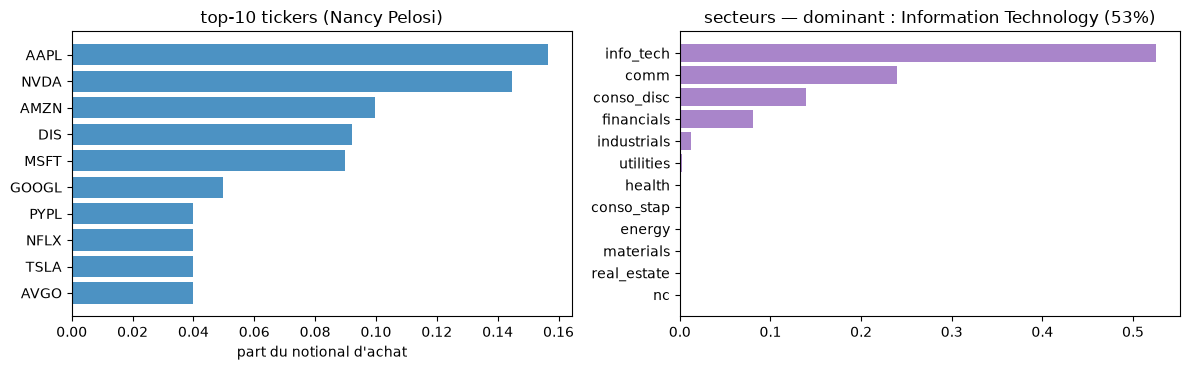

In [31]:
_r = M.loc[DEMO_BID]
_tk10 = _r["top10_tickers"].split("|")
_parts10 = (dfx[(dfx.bioguide_id == DEMO_BID) & (dfx.op == "buy")]
            .groupby("ticker")["size_usd"].sum().reindex(_tk10) / _r["notional_buy"])
_sc = list(SECT_COLS.values()) + ["sect_nc"]
_sv = _r[_sc].astype(float).sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].barh(_tk10[::-1], _parts10.values[::-1], color=C_M, alpha=.8)
ax[0].set_title(f"top-10 tickers ({DEMO_NOM})"); ax[0].set_xlabel("part du notional d'achat")
ax[1].barh([s.replace('sect_', '') for s in _sv.index[::-1]], _sv.values[::-1], color="tab:purple", alpha=.8)
ax[1].set_title(f"secteurs — dominant : {_r['sect_dom']} ({_r['part_sect_dom']:.0%})")
plt.tight_layout(); plt.show()

## §7 `membres` — risque et performance

**But** : le risque et la performance du portefeuille de chaque membre, mesurés sur sa série de
rendement quotidienne $r_m$. Chaque mesure en une phrase :

- **cagr** : croissance annualisée du portefeuille ;
- **vol** : volatilité — l'ampleur typique des variations, annualisée ;
- **sharpe** : rendement moyen par unité de volatilité (qualité du couple rendement/risque) ;
- **sortino** : comme le Sharpe, mais seule la volatilité des jours de baisse pénalise ;
- **maxdd** (max drawdown) : la pire perte depuis un sommet ;
- **beta** : sensibilité au marché (1 = bouge comme le SPY) ;
- **alpha_ann** : ce qui reste, annualisé, une fois l'effet marché retiré ;
- **ir** (information ratio) : écart moyen au SPY rapporté à la régularité de cet écart ;
- **appraisal** : l'alpha rapporté au risque non expliqué par le marché ;
- les **t** (`t_sharpe`, `t_ir`, `t_appr`) : statistiques de Student — combien d'écarts-types
  séparent la mesure de zéro ; $|t| \ge 2$ ≈ difficilement attribuable au hasard.

$$\texttt{sharpe}_m = \frac{\bar r_m}{\sigma(r_m)}\sqrt{252}, \qquad
\texttt{ir}_m = \frac{\overline{r_m - r_{SPY}}}{\sigma(r_m - r_{SPY})}\sqrt{252}, \qquad
r_m = \alpha + \beta\, r_{SPY} + \varepsilon
\;\Rightarrow\; \texttt{appraisal}_m = \frac{\alpha}{\sigma_\varepsilon}\sqrt{252}$$

Attention de lecture : si un membre ne détient qu'un seul titre, la « vol » calculée est celle de
ce titre — le chiffre est exact, mais il ne décrit pas une gestion de portefeuille. Les colonnes
`n_eff` (§4) et `eligible` servent à filtrer ces cas.

In [32]:
_rows = {}
for b, r in wf_ret.items():
    st = stats(r); ab = alpha_beta(r)
    T = len(r)
    _rows[b] = dict(cagr=st["cagr"], vol=st["vol"], sharpe=st["sharpe"], maxdd=st["maxdd"],
                    sortino=sortino(r),
                    t_sharpe=st["sharpe"] * np.sqrt(T / 252) if np.isfinite(st["sharpe"]) else np.nan,
                    ir=info_ratio(r), beta=ab["beta"], alpha_ann=ab["alpha_ann"],
                    appraisal=ab["appraisal"], t_appr=ab["t_appr"],
                    exces_cagr_spy=exces_spy(b))
_perf = pd.DataFrame(_rows).T
_perf["t_ir"] = _perf["ir"] * np.sqrt(M["n_days"].reindex(_perf.index) / 252)
for c in _perf.columns:
    M[c] = _perf[c]
M["eligible"] = (M["n_trades"].fillna(0) >= 10) & (M["n_days"].fillna(0) >= 126)
print(f"risque/perf : {len(_perf)} membres | éligibles : {int(M.eligible.sum())}")

risque/perf : 266 membres | éligibles : 223


### §7.1 Contrôles

**Méthodes** : deuxième méthode — la régression $\alpha/\beta$ est recalculée par les formules
fermées $\beta = \mathrm{cov}(r_m, r_{SPY})/\mathrm{var}(r_{SPY})$ sur un membre, et doit
coïncider avec le calcul principal ; bornes de bon sens sur les éligibles ; le compte des
éligibles = la chaîne du §0.1.

In [33]:
assert int(M["eligible"].sum()) == 223
# 2e méthode : beta = cov(r, r_spy)/var(r_spy), alpha = r̄ − beta·r̄_spy — formules fermées
_b7 = M[M.eligible].sort_values("n_days", ascending=False).index[0]
_r7 = wf_ret[_b7]
_d7 = pd.concat([_r7.rename("y"), r_spy.reindex(_r7.index).rename("x")], axis=1).dropna()
_beta2 = _d7["y"].cov(_d7["x"]) / _d7["x"].var()
_alpha2 = _d7["y"].mean() - _beta2 * _d7["x"].mean()
assert abs(_beta2 - M.loc[_b7, "beta"]) < 1e-10
assert abs((1 + _alpha2) ** 252 - 1 - M.loc[_b7, "alpha_ann"]) < 1e-10
# bornes de vraisemblance
_e = M[M.eligible]
assert _e["vol"].between(0, 3).all() and _e["beta"].dropna().between(-2, 5).all()
assert _e["maxdd"].between(-1, 0).all()
print(f"§7.1 OK — 223 éligibles | régression : les deux méthodes coïncident sur {M.loc[_b7, 'name']} | "
      f"vol médiane des éligibles {_e.vol.median():.1%}")

§7.1 OK — 223 éligibles | régression : les deux méthodes coïncident sur Tammy Duckworth | vol médiane des éligibles 20.4%


**Aperçu** — risque et performance, sur les 8 éligibles qui ont le plus de trades :

In [34]:
(M[M.eligible].sort_values("n_trades", ascending=False)
  [["name", "cagr", "vol", "sharpe", "sortino", "maxdd", "beta", "alpha_ann", "ir", "exces_cagr_spy"]]
  .head(8).round(3))

,name,cagr,vol,sharpe,sortino,maxdd,beta,alpha_ann,ir,exces_cagr_spy
bioguide_id,,,,,,,,,,
K000389,Rohit Khanna,0.155,0.185,0.869,1.047,-0.376,0.978,0.005,0.040,0.002
M001157,Michael T. McCaul,0.104,0.191,0.613,0.768,-0.392,1.020,-0.031,-0.371,-0.035
R000586,James B. Renacci,0.108,0.164,0.709,0.874,-0.343,0.928,-0.017,-0.667,-0.029
G000583,Josh Gottheimer,0.145,0.198,0.783,0.996,-0.319,1.044,-0.012,-0.085,-0.009
R000582,David P. Roe,0.142,0.175,0.847,1.056,-0.348,0.987,0.005,0.072,0.003
M001193,Thomas MacArthur,0.105,0.163,0.695,0.843,-0.349,0.887,-0.016,-0.640,-0.034
H001086,Diana Harshbarger,0.148,0.173,0.884,1.263,-0.167,0.893,0.016,-0.010,-0.002
C001123,Gilbert Cisneros,0.179,0.220,0.857,1.074,-0.370,1.087,-0.000,0.230,0.011


### §7.2 Démo — son portefeuille contre le marché

**Lecture :** en haut, la valeur de 100 $ investis « comme lui » (bleu) contre 100 $ dans le SPY
sur la même période (gris), échelle log ; en bas, son drawdown. Le titre donne ses mesures de
risque/performance.

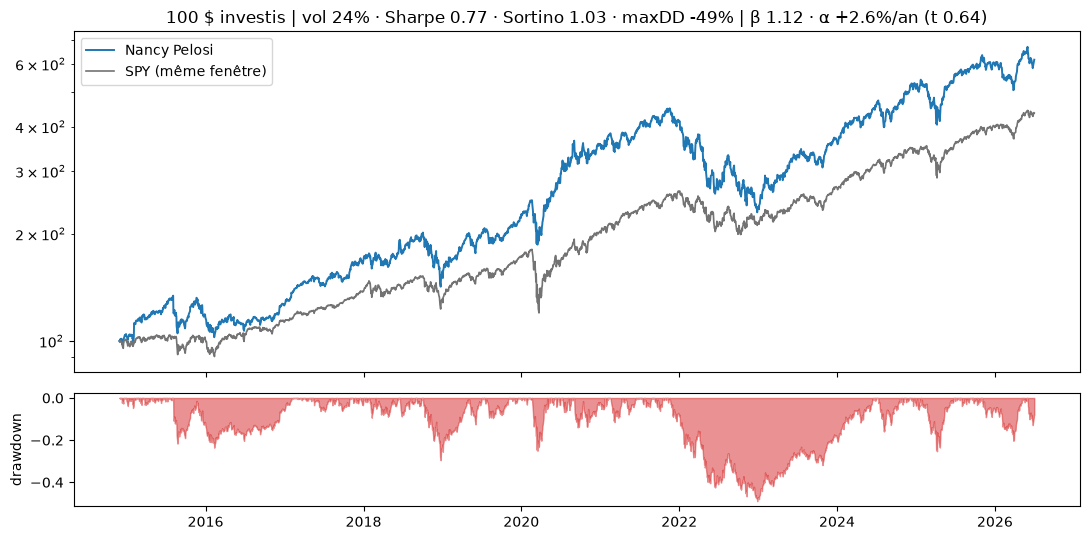

excès de croissance vs SPY : +3.4%/an | IR 0.31 (t 1.06) | 2914 jours actifs | éligible : oui


In [35]:
assert DEMO_BID in wf_ret, "membre non reconstruit : choisis-en un autre au §1.2"
_rm = wf_ret[DEMO_BID]
_nav = (1 + _rm).cumprod() * 100
_rs = r_spy.reindex(_rm.index).fillna(0.0); _navs = (1 + _rs).cumprod() * 100
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(_nav, color=C_M, lw=1.4, label=DEMO_NOM)
ax[0].plot(_navs, color=C_SPY, lw=1.2, label="SPY (même fenêtre)")
ax[0].set_yscale("log"); ax[0].legend()
_r = M.loc[DEMO_BID]
ax[0].set_title(f"100 $ investis | vol {_r['vol']:.0%} · Sharpe {_r['sharpe']:.2f} · Sortino {_r['sortino']:.2f} · "
                f"maxDD {_r['maxdd']:.0%} | β {_r['beta']:.2f} · α {_r['alpha_ann']:+.1%}/an (t {_r['t_appr']:.2f})")
ax[1].fill_between(_nav.index, (_nav / _nav.cummax() - 1).values, color=C_SELL, alpha=.5)
ax[1].set_ylabel("drawdown")
plt.tight_layout(); plt.show()
print(f"excès de croissance vs SPY : {_r['exces_cagr_spy']:+.1%}/an | IR {_r['ir']:.2f} (t {_r['t_ir']:.2f}) | "
      f"{int(_r['n_days'])} jours actifs | éligible : {'oui' if _r['eligible'] else 'non'}")

## §8 `membres` — le track record par trade

**But** : le talent trade par trade — pour chaque **achat**, le titre acheté a-t-il fait mieux que
le marché entre l'achat et la revente ?

La règle, pour chaque achat $j$ : entrée au prix du 1er jour de bourse après $\tau_j$ ; sortie à la
**première vente** du même titre par le même membre — ou au bout d'un an s'il ne revend pas :

$$t^s_j = \min\big(\text{première vente de } (m_j, k_j) \text{ après } \tau_j,\; \tau_j + 252 \text{ j de bourse}\big)$$

$$x_j = \underbrace{\frac{P_{k_j}(t^s_j)}{P_{k_j}(\tau_j^+)} - 1}_{\text{rendement du titre}}
\;-\; \underbrace{\Big(\frac{SPY(t^s_j)}{SPY(\tau_j^+)} - 1\Big)}_{\text{rendement du marché}}
\qquad (\text{brut de frais : on mesure le membre, pas un copieur})$$

Les colonnes qui en découlent, chacune en une phrase :

- `hit_rate` $= \mathbb{P}(x_j > 0)$ : la part de ses achats qui battent le marché ;
- `exces_moyen_trade` / `exces_med_trade` : l'excès moyen / médian par achat ;
- `ret_brut_moyen_trade` : le rendement brut moyen (sans soustraire le marché) ;
- `profit_factor` $= \sum x_j^+ / |\sum x_j^-|$ : le total des excès gagnés rapporté au total
  perdu (plafonné à 10 ; > 1 = il gagne plus qu'il ne perd) ;
- `t_exces_trade` : le t de Student de l'excès moyen.

In [36]:
# appariement : chaque achat -> la première vente ultérieure du même (membre, ticker)
_b = dfx[dfx.op == "buy"][["bioguide_id", "ticker", "traded"]].sort_values("traded").reset_index()
_s = (dfx[dfx.op == "sell"][["bioguide_id", "ticker", "traded"]].dropna()
      .sort_values("traded").rename(columns={"traded": "sortie_vente"}))
_paires = pd.merge_asof(_b, _s, left_on="traded", right_on="sortie_vente",
                        by=["bioguide_id", "ticker"], direction="forward", allow_exact_matches=False)
_b["sortie_vente"] = _paires["sortie_vente"].values

# excès vectorisé : entrée J+1 de la transaction, sortie min(vente, +252 j), brut de frais
px = pd.DataFrame(prices)                       # prix déjà alignés sur le calendrier
PXV = px.to_numpy(); SPYV = spy.to_numpy()
COL = {tk: i for i, tk in enumerate(px.columns)}
# garde anti-prix périmé : dernier jour de VRAIE cotation par ticker (fichier brut)
_last_true = {}
for tk in need:
    _d = pd.read_csv(os.path.join(PRICES, tk + ".csv"), usecols=["Date"])["Date"]
    _last_true[tk] = cal.searchsorted(pd.Timestamp(_d.iloc[-1]), side="right") - 1
_LAST = np.array([_last_true[tk] for tk in px.columns])

HOLD_MAX = 252
i0 = cal.searchsorted(pd.DatetimeIndex(_b["traded"]), side="right")
i_v = cal.searchsorted(pd.DatetimeIndex(pd.Series(_b["sortie_vente"]).fillna(cal[-1])), side="right")
i1 = np.where(_b["sortie_vente"].isna(), i0 + HOLD_MAX, np.minimum(i_v, i0 + HOLD_MAX))
i1 = np.minimum(np.maximum(i1, i0 + 1), len(cal) - 1)
cols = np.array([COL.get(t, -1) for t in _b["ticker"]])
ok = (cols >= 0) & (i0 < len(cal) - 1) & (i0 <= _LAST[np.maximum(cols, 0)])   # entrée sur une vraie cote
x = np.full(len(_b), np.nan); xr = np.full(len(_b), np.nan)
r_, c0, c1 = cols[ok], i0[ok], np.asarray(i1)[ok]
p0, p1 = PXV[c0, r_], PXV[c1, r_]
b0, b1 = SPYV[c0], SPYV[c1]
valid = ~(np.isnan(p0) | np.isnan(p1)) & (p0 > 0) & (b0 > 0)
_res = np.full(int(ok.sum()), np.nan); _resr = np.full(int(ok.sum()), np.nan)
_res[valid] = (p1[valid] / p0[valid] - 1) - (b1[valid] / b0[valid] - 1)
_resr[valid] = p1[valid] / p0[valid] - 1
x[ok] = _res; xr[ok] = _resr
_b["x"], _b["x_raw"] = x, xr
_bt = _b.dropna(subset=["x"])
print(f"{len(_bt):,} achats évalués / {len(_b):,} | excès moyen {_bt.x.mean():+.2%} | médiane {_bt.x.median():+.2%}")

59,128 achats évalués / 60,154 | excès moyen -0.14% | médiane -1.60%


In [37]:
_g = _bt.groupby("bioguide_id")["x"]
M["n_trades_evalues"] = _g.size()
M["hit_rate"] = _g.agg(lambda a: (a > 0).mean())
M["exces_moyen_trade"] = _g.mean()
M["exces_med_trade"] = _g.median()
M["ret_brut_moyen_trade"] = _bt.groupby("bioguide_id")["x_raw"].mean()
M["profit_factor"] = _g.agg(lambda a: min(a[a > 0].sum() / abs(a[a <= 0].sum()), 10.0)
                            if (a <= 0).any() and a[a <= 0].sum() != 0 else 10.0)
M["t_exces_trade"] = _g.agg(lambda a: a.mean() / (a.std(ddof=1) / np.sqrt(len(a)) + 1e-12)
                            if len(a) > 1 else np.nan)
print(f"track record : {int(M.n_trades_evalues.notna().sum())} membres avec au moins un achat évalué "
      f"(un achat trop récent, ou sans cotation à l'entrée, n'est pas évaluable)")

track record : 267 membres avec au moins un achat évalué (un achat trop récent, ou sans cotation à l'entrée, n'est pas évaluable)


### §8.1 Contrôles

**Méthodes** : recalcul à la main d'un trade réel, pas à pas (prix d'entrée, prix de sortie,
rendements) — le résultat doit être identique au calcul vectorisé ; puis bornes logiques.

In [38]:
# (i) un achat NVDA de Nancy Pelosi, recalculé pas à pas
#     (exemple fixé en dur : ce contrôle ne dépend pas du membre de démonstration du §1.2)
PELOSI_BID = df.loc[df["name"] == "Nancy Pelosi", "bioguide_id"].iloc[0]
_ex = _bt[(_bt.bioguide_id == PELOSI_BID) & (_bt.ticker == "NVDA")].iloc[0]
_i0 = cal.searchsorted(_ex["traded"], side="right")
_iv = cal.searchsorted(_ex["sortie_vente"], side="right") if pd.notna(_ex["sortie_vente"]) else _i0 + HOLD_MAX
_i1 = min(max(min(_iv, _i0 + HOLD_MAX), _i0 + 1), len(cal) - 1)
_pn = prices["NVDA"]
_x_main = (_pn.iloc[_i1] / _pn.iloc[_i0] - 1) - (spy.iloc[_i1] / spy.iloc[_i0] - 1)
assert abs(_x_main - _ex["x"]) < 1e-12, (_x_main, _ex["x"])
print(f"trade contrôlé : achat NVDA du {_ex['traded'].date()} | entrée {cal[_i0].date()} "
      f"sortie {cal[_i1].date()} | excès à la main {_x_main:+.2%} = vectorisé {_ex['x']:+.2%}")
# (ii) bornes et cohérences
assert (M["n_trades_evalues"].fillna(0) <= M["n_buy"].fillna(0)).all()
assert M["hit_rate"].dropna().between(0, 1).all()
assert M["profit_factor"].dropna().between(0, 10).all()
assert abs(_bt.x.mean()) < 0.05          # ordre de grandeur : l'excès moyen par trade reste < 5 %
print(f"§8.1 OK — recalcul à la main identique | bornes respectées | excès moyen global {_bt.x.mean():+.2%}")

trade contrôlé : achat NVDA du 2021-07-23 | entrée 2021-07-26 sortie 2022-07-26 | excès à la main -4.15% = vectorisé -4.15%
§8.1 OK — recalcul à la main identique | bornes respectées | excès moyen global -0.14%


**Aperçu** — le track record par trade, sur les 8 plus gros échantillons (nombre d'achats évalués) :

In [39]:
(M.sort_values("n_trades_evalues", ascending=False)
  [["name", "n_trades_evalues", "hit_rate", "exces_moyen_trade", "exces_med_trade",
    "ret_brut_moyen_trade", "profit_factor", "t_exces_trade"]]
  .head(8).round(3))

,name,n_trades_evalues,hit_rate,exces_moyen_trade,exces_med_trade,ret_brut_moyen_trade,profit_factor,t_exces_trade
bioguide_id,,,,,,,,
K000389,Rohit Khanna,18421.0,0.401,-0.007,-0.020,0.037,0.877,-4.850
M001157,Michael T. McCaul,7044.0,0.470,0.011,-0.005,0.099,1.166,3.931
R000586,James B. Renacci,2056.0,0.482,0.002,-0.006,0.072,1.033,0.508
M001193,Thomas MacArthur,1367.0,0.394,-0.018,-0.019,0.042,0.701,-3.812
C001123,Gilbert Cisneros,1325.0,0.429,0.030,-0.030,0.170,1.286,2.668
R000582,David P. Roe,1260.0,0.448,-0.006,-0.014,0.074,0.917,-0.916
G000583,Josh Gottheimer,1253.0,0.433,-0.000,-0.033,0.091,0.999,-0.007
H001086,Diana Harshbarger,1015.0,0.496,-0.008,-0.003,0.020,0.889,-1.248


### §8.2 Démo — la distribution de ses excès par trade

**Lecture :** chaque achat donne un excès $x_j$ (le titre a fait $x_j$ de mieux — ou de moins
bien — que le SPY entre l'achat et la revente). L'histogramme montre tous ses $x_j$ : à droite de
la ligne noire, les achats qui ont battu le marché.

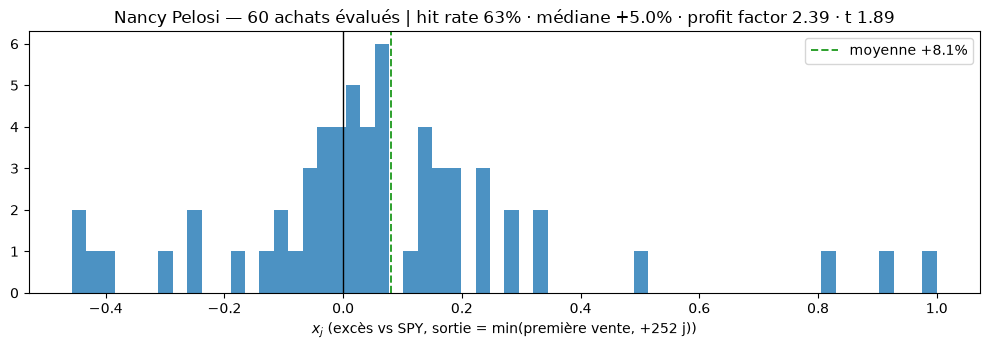

In [40]:
_x = _bt.loc[_bt.bioguide_id == DEMO_BID, "x"]
_r = M.loc[DEMO_BID]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(_x.clip(-1, 1), bins=60, color=C_M, alpha=.8)
ax.axvline(0, color="k", lw=1)
ax.axvline(_x.mean(), color=C_BUY if _x.mean() > 0 else C_SELL, ls="--", lw=1.4,
           label=f"moyenne {_x.mean():+.1%}")
ax.set_title(f"{DEMO_NOM} — {int(_r['n_trades_evalues'])} achats évalués | "
             f"hit rate {_r['hit_rate']:.0%} · médiane {_r['exces_med_trade']:+.1%} · "
             f"profit factor {_r['profit_factor']:.2f} · t {_r['t_exces_trade']:.2f}")
ax.set_xlabel("$x_j$ (excès vs SPY, sortie = min(première vente, +252 j))"); ax.legend()
plt.tight_layout(); plt.show()

## §9 `membres` — comportement

**But** : trois comportements, chacun avec son intérêt :

- `part_ci_achats` — **alignement comité** : la part de ses achats dans un secteur que ses
  comités supervisent (matrice du §1). Intérêt : un conflit d'intérêts potentiel — il achète là
  où il a l'information et le pouvoir.
- `part_trades_repetes` — **répétition** : la part de ses trades sur un titre qu'il a *déjà*
  tradé avant. Intérêt : distingue le suivi de quelques convictions (ou les allers-retours
  spéculatifs) de la découverte permanente de nouveaux titres.
- `part_coachat` — **co-achat** : la part de ses achats faits sur un (titre, mois) où au moins
  3 membres achètent en même temps. Intérêt : achète-t-il ce que tout le monde achète (suivisme)
  ou en solitaire ?

$$\texttt{part\_ci\_achats}_m = \mathbb{P}_j\big(\mathrm{GICS}(k_j) \in \mathcal{J}(\texttt{comites}_j)
\;\big|\; d_j = \text{buy}\big), \qquad
\texttt{part\_trades\_repetes}_m = \mathbb{P}_j\big(\exists\, j' : k_{j'} = k_j,\ \tau_{j'} < \tau_j\big)$$

$$\texttt{part\_coachat}_m = \mathbb{P}_j\big(\#\{m' \text{ acheteurs de } k_j \text{ le même mois}\} \ge 3
\;\big|\; d_j = \text{buy}\big)$$

Le drapeau d'alignement est calculé trade par trade, avec les comités **portés par le trade
lui-même** (les comités du membre au moment du dépôt — pas ses comités d'aujourd'hui).

In [41]:
# alignement comité×secteur, trade par trade
_codes_tr = dfx["committee_membership"].map(codes_racine)
_juri_tr = _codes_tr.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
dfx["ci"] = [s in sm for s, sm in zip(dfx["sector_gics"], _juri_tr)]
M["part_ci_achats"] = dfx[dfx.op == "buy"].groupby("bioguide_id")["ci"].mean()

# répétition : trade sur un ticker déjà tradé avant par le même membre
_o = dfx.sort_values("traded")
dfx["repete"] = _o.groupby(["bioguide_id", "ticker"]).cumcount().reindex(dfx.index) > 0
M["part_trades_repetes"] = dfx.groupby("bioguide_id")["repete"].mean()

# co-achat : (ticker, mois) avec >= 3 acheteurs distincts
_bm = dfx[dfx.op == "buy"].copy()
_bm["ym"] = _bm["traded"].dt.to_period("M")
_co = _bm.groupby(["ym", "ticker"])["bioguide_id"].transform("nunique")
_bm["coachat3"] = _co >= 3
M["part_coachat"] = _bm.groupby("bioguide_id")["coachat3"].mean()
print(f"comportement : part d'achats alignés comité (tous trades confondus) = "
      f"{dfx.loc[dfx.op == 'buy', 'ci'].mean():.1%}")

comportement : part d'achats alignés comité (tous trades confondus) = 0.0%


### §9.1 Contrôles

**Méthodes** : recalcul à la main du drapeau d'alignement sur 3 achats réels (comités du trade
→ secteurs supervisés → le secteur du titre y est-il ?), puis bornes.

In [42]:
# (i) recalcul à la main sur 3 achats réels tirés au hasard (graine fixe)
_ech = dfx[dfx.op == "buy"].sample(3, random_state=7)
for _, _t in _ech.iterrows():
    _cods = codes_racine(_t["committee_membership"])
    _secs = frozenset().union(*[COMITE_GICS.get(c, set()) for c in _cods]) if _cods else frozenset()
    _attendu = _t["sector_gics"] in _secs
    assert bool(_t["ci"]) == _attendu, _t["ticker"]
    print(f"  {_t['name_canon'][:22]:22s} achète {str(_t['ticker']):6s} ({str(_t['sector_gics'])[:22]:22s}) | "
          f"comités {'|'.join(sorted(_cods)) or '—':28s} -> aligné : {_attendu}")
# (ii) bornes
for c in ("part_ci_achats", "part_trades_repetes", "part_coachat"):
    assert M[c].dropna().between(0, 1).all(), c
print("§9.1 OK — drapeau d'alignement recalculé à la main sur 3 trades | bornes [0, 1] respectées")

  Bruce Westerman        achète SU     (Energy                ) | comités —                            -> aligné : False
  Rohit Khanna           achète PPG    (Materials             ) | comités —                            -> aligné : False
  Lois Frankel           achète MRK    (Health Care           ) | comités —                            -> aligné : False
§9.1 OK — drapeau d'alignement recalculé à la main sur 3 trades | bornes [0, 1] respectées


**Aperçu** — le comportement, sur les 8 membres qui ont le plus de trades :

In [43]:
(M.sort_values("n_trades", ascending=False)
  [["name", "part_ci_achats", "part_trades_repetes", "part_coachat"]]
  .head(8).round(3))

,name,part_ci_achats,part_trades_repetes,part_coachat
bioguide_id,,,,
K000389,Rohit Khanna,0.0,0.970,0.086
M001157,Michael T. McCaul,0.0,0.964,0.086
R000586,James B. Renacci,0.0,0.860,0.061
G000583,Josh Gottheimer,0.0,0.843,0.165
R000582,David P. Roe,0.0,0.865,0.183
M001193,Thomas MacArthur,0.0,0.835,0.089
H001086,Diana Harshbarger,0.0,0.932,0.138
C001123,Gilbert Cisneros,0.0,0.736,0.115


### §9.2 Démo — son comportement, comparé aux autres

**Lecture :** ses trois parts de comportement (bleu) face à la médiane des 223 membres éligibles
(gris). Une barre bleue nettement au-dessus du gris = un trait marqué chez ce membre.

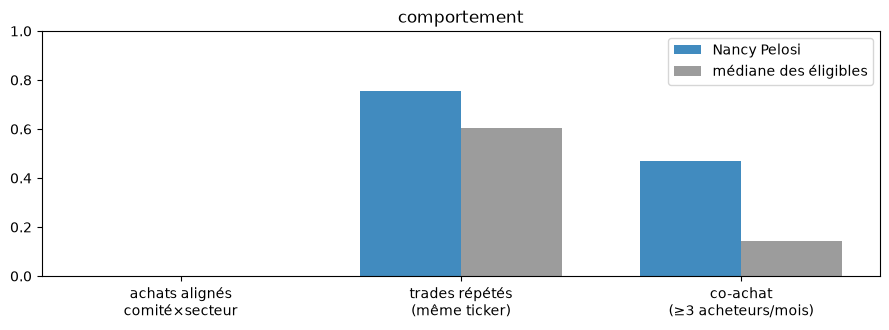

In [44]:
_r = M.loc[DEMO_BID]; _e = M[M.eligible]
_labels = ["achats alignés\ncomité×secteur", "trades répétés\n(même ticker)", "co-achat\n(≥3 acheteurs/mois)"]
_cols = ["part_ci_achats", "part_trades_repetes", "part_coachat"]
fig, ax = plt.subplots(figsize=(9, 3.4))
_xpos = np.arange(3)
ax.bar(_xpos - 0.18, [_r[c] for c in _cols], 0.36, color=C_M, alpha=.85, label=DEMO_NOM)
ax.bar(_xpos + 0.18, [_e[c].median() for c in _cols], 0.36, color=C_SPY, alpha=.7, label="médiane des éligibles")
ax.set_xticks(_xpos); ax.set_xticklabels(_labels); ax.set_ylim(0, 1); ax.legend()
ax.set_title("comportement")
plt.tight_layout(); plt.show()

## §10 `tickers` — identité et flux Congrès

**But** : la même donnée vue par titre — qui du Congrès achète/vend chaque action, combien, quand.

$\mathcal{K}$ = les 4 607 tickers de $\mathcal{T}^{brut}$. L'identité est prise par mode (valeur
la plus fréquente sur les trades du ticker) ; les flux sont comptés sur $\mathcal{T}$, sauf
`n_trades_brut` :

$$\texttt{notional\_net}_k = \sum_{j : k_j = k,\, d_j = \text{buy}} A_j - \sum_{j : k_j = k,\, d_j = \text{sell}} A_j
\;(\text{achats moins ventes, en \$}),
\qquad
\texttt{part\_dem}_k = \frac{\sum_{j\,\text{buy},\ \text{Democrat}} A_j}{\sum_{j\,\text{buy}} A_j}$$

$$\texttt{coachat\_max}_k = \max_{\text{mois}} \#\{m : m \text{ achète } k \text{ ce mois}\}
\;(\text{record mensuel d'acheteurs}), \qquad
\texttt{n\_mois\_actifs}_k = \#\{(\text{année},\text{mois}) : \exists\, j\}$$

Colonnes d'identité : `description` (nom du titre tel que déclaré), `asset_class`
(action / ETF), `is_broad_etf` (ETF large type S&P 500), `sector_gics` et `etf_proxy` (l'ETF
sectoriel correspondant), `is_delisted` / `delist_type` (titre sorti de la cote : rachat,
faillite…), `flag_price_caution` (série de prix à manier avec prudence).

In [45]:
_tb = dfb.groupby("ticker")
K = pd.DataFrame(index=pd.Index(sorted(dfb.ticker.dropna().unique()), name="ticker"))
K["description"] = _tb["asset_description"].agg(_mode).astype(str).str[:80]
K["asset_class"] = _tb["asset_class"].agg(_mode)
K["is_broad_etf"] = _tb["is_broad_etf"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())
K["sector_gics"] = _tb["sector_gics"].agg(_mode)
K["etf_proxy"] = _tb["etf_proxy"].agg(_mode)
K["is_delisted"] = _tb["is_delisted"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())
K["delist_type"] = _tb["delist_type"].agg(_mode)
K["flag_price_caution"] = _tb["flag_price_caution"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())

_tx = dfx.groupby("ticker")
K["n_trades_brut"] = _tb.size()
K["n_trades"] = _tx.size()
K["n_buy"] = _tx["op"].agg(lambda s: int((s == "buy").sum()))
K["n_sell"] = _tx["op"].agg(lambda s: int((s == "sell").sum()))
K["notional_buy"] = dfx[dfx.op == "buy"].groupby("ticker")["size_usd"].sum()
K["notional_sell"] = dfx[dfx.op == "sell"].groupby("ticker")["size_usd"].sum()
K["notional_net"] = K["notional_buy"].fillna(0) - K["notional_sell"].fillna(0)
K["n_membres"] = _tx["bioguide_id"].nunique()
K["n_membres_buy"] = dfx[dfx.op == "buy"].groupby("ticker")["bioguide_id"].nunique()
K["n_membres_sell"] = dfx[dfx.op == "sell"].groupby("ticker")["bioguide_id"].nunique()
_dem = dfx[(dfx.op == "buy") & (dfx.party == "Democrat")].groupby("ticker")["size_usd"].sum()
K["part_dem"] = (_dem / K["notional_buy"]).where(K["notional_buy"].notna())
K["part_senate"] = _tx["chamber"].agg(lambda s: (s == "senate").mean())
K["part_conjoint"] = _tx["owner_n"].agg(lambda s: (s == "conjoint").mean())
K["part_ci_achats"] = dfx[dfx.op == "buy"].groupby("ticker")["ci"].mean()
K["first_trade"] = _tx["traded"].min().dt.date
K["last_trade"] = _tx["traded"].max().dt.date
K["n_mois_actifs"] = _tx["traded"].agg(lambda s: s.dt.to_period("M").nunique())
K["coachat_max"] = _bm.groupby(["ticker", "ym"])["bioguide_id"].nunique().groupby(level=0).max()
_tm = dfx.groupby(["ticker", "bioguide_id"])["size_usd"].sum().sort_values(ascending=False)
_tm3 = (_tm.groupby(level=0).head(3).reset_index()
        .sort_values(["ticker", "size_usd"], ascending=[True, False]))
K["top_membres"] = _tm3.groupby("ticker")["bioguide_id"].agg("|".join)
print(f"K : {len(K)} tickers × {K.shape[1]} colonnes")

K : 4607 tickers × 27 colonnes


### §10.1 Contrôles

**Méthodes** : recoupements de sommes + recalcul à la main du ticker le plus tradé + bornes.

In [46]:
assert len(K) == 4607 and K.index.is_unique, len(K)
assert int(K["n_trades_brut"].sum()) == 134417
assert int(K["n_trades"].fillna(0).sum()) == 118316
assert int(K["n_trades"].notna().sum()) == 3286          # tickers de 𝒯 = ceux couverts prix
assert K["part_dem"].dropna().between(0, 1).all() and K["part_senate"].dropna().between(0, 1).all()
# recalcul à la main : le ticker le plus tradé, compté directement
_k0 = K["n_trades"].idxmax()
_subk = dfx[dfx.ticker == _k0]
assert int(K.loc[_k0, "n_trades"]) == len(_subk)
assert int(K.loc[_k0, "n_membres"]) == _subk["bioguide_id"].nunique()
assert abs(K.loc[_k0, "notional_buy"] - _subk.loc[_subk.op == "buy", "size_usd"].sum()) < 0.01
print(f"§10.1 OK — 4 607 tickers, sommes exactes | recalcul direct identique sur {_k0} "
      f"({int(K.loc[_k0, 'n_trades'])} trades, {int(K.loc[_k0, 'n_membres'])} membres)")

§10.1 OK — 4 607 tickers, sommes exactes | recalcul direct identique sur AAPL (1260 trades, 151 membres)


**Aperçu** — identité et flux, sur les 8 tickers les plus tradés par le Congrès :

In [47]:
(K.sort_values("n_trades", ascending=False)
  [["description", "sector_gics", "n_trades", "n_buy", "n_sell", "notional_buy", "notional_net",
    "n_membres", "coachat_max", "first_trade", "last_trade"]]
  .head(8).round(0))

,description,sector_gics,n_trades,n_buy,n_sell,notional_buy,notional_net,n_membres,coachat_max,first_trade,last_trade
ticker,,,,,,,,,,,
AAPL,Apple Inc.,Information Technology,1260.0,585.0,675.0,28947652.0,-56738706.0,151.0,12.0,2013-04-19,2026-06-16
MSFT,Microsoft Corporation,Information Technology,1238.0,606.0,632.0,93307910.0,-34664830.0,144.0,14.0,2013-07-19,2026-06-16
AMZN,"Amazon.com, Inc.",Consumer Discretionary,976.0,565.0,411.0,29045136.0,4215428.0,126.0,10.0,2013-05-09,2026-06-16
GOOGL,ALPHABET INC. CMN CLASS A,Communication Services,885.0,399.0,486.0,14792200.0,-12171544.0,95.0,6.0,2013-01-17,2026-06-16
META,"Meta Platforms, Inc. - Class A Common Stock",Communication Services,849.0,436.0,413.0,15088444.0,-7199008.0,90.0,6.0,2013-09-13,2026-06-16
NVDA,NVIDIA Corporation - Common Stock,Information Technology,660.0,372.0,288.0,26357565.0,2635421.0,74.0,8.0,2015-05-14,2026-06-16
DIS,WALT DISNEY COMPANY (THE) CMN,Communication Services,656.0,362.0,294.0,12792181.0,3030034.0,97.0,8.0,2013-12-31,2026-05-27
UNH,UNITEDHEALTH GROUP INC,Health Care,646.0,302.0,344.0,10682152.0,-168160.0,80.0,9.0,2013-04-26,2026-05-15


## §11 `tickers` — marché et après-achats

**But** : le profil de marché de chaque titre (volatilité, bêta, liquidité) et ce que fait le
titre dans les semaines qui suivent les achats du Congrès.

**Marché** — calculé sur la série de prix **brute** (les jours réellement cotés). Pour
reconstruire les portefeuilles, les prix sont prolongés au dernier cours connu ; ici on ne le fait
pas : pour un titre sorti de la cote, ce prolongement fabriquerait des rendements nuls et une
volatilité artificiellement basse.

- `vol_ann` : volatilité annualisée du titre ; `beta_spy` : sensibilité au marché ;
- `adv_med` : volume moyen d'échanges en dollars par jour (médiane sur l'historique) — mesure de
  liquidité ;
- `cagr_fenetre`, `ret_total`, `maxdd` : croissance annualisée, rendement total et pire perte sur
  la fenêtre observée (`px_first` → `px_last`).

$$\texttt{vol\_ann}_k = \sigma\big(\Delta \log P_k\big)\sqrt{252}, \qquad
\texttt{beta\_spy}_k = \frac{\operatorname{cov}(r_k, r_{SPY})}{\operatorname{var}(r_{SPY})}
\;\;(\ge 126 \text{ jours communs}), \qquad
\texttt{adv\_med}_k = \operatorname{med}_t\big(P^{brut}_k(t)\, \mathrm{Vol}_k(t)\big)$$

**Après-achats** — pour chaque achat du Congrès sur le titre, le titre a-t-il fait mieux que le
SPY dans les 21 jours (≈ 1 mois) et 63 jours (≈ 3 mois) de bourse qui suivent ? Moyenne par
ticker (descriptif, brut de frais) :

$$\texttt{exces\_H}_k = \overline{\Big[\tfrac{P_k(\tau_j^+ + H)}{P_k(\tau_j^+)}
- \tfrac{SPY(\tau_j^+ + H)}{SPY(\tau_j^+)}\Big]}_{j\,:\,k_j = k,\ d_j = \text{buy}},
\qquad H \in \{21, 63\}$$

In [48]:
VOLDIR = os.path.join(BASE, "cache", "volume_v1")
_mkt = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index().dropna())
    lr = np.log(s).diff().dropna()
    row = dict(px_first=s.index[0].date(), px_last=s.index[-1].date(), px_n_obs=len(s),
               vol_ann=float(lr.std() * np.sqrt(252)) if len(lr) > 20 else np.nan,
               ret_total=float(s.iloc[-1] / s.iloc[0] - 1),
               cagr_fenetre=float((s.iloc[-1] / s.iloc[0]) ** (252 / max(len(s), 1)) - 1) if len(s) > 20 else np.nan,
               maxdd=float((s / s.cummax() - 1).min()))
    _rk = s.pct_change().dropna()
    _pair = pd.concat([_rk.rename("y"), r_spy.reindex(_rk.index).rename("x")], axis=1).dropna()
    row["beta_spy"] = float(np.polyfit(_pair["x"], _pair["y"], 1)[0]) if len(_pair) >= 126 else np.nan
    _vf = os.path.join(VOLDIR, tk + ".csv")
    if os.path.exists(_vf):
        _v = pd.read_csv(_vf)
        row["adv_med"] = float((_v["close_raw"] * _v["volume"]).median())
    else:
        row["adv_med"] = np.nan
    _mkt[tk] = row
_mkt = pd.DataFrame(_mkt).T
K["px_couvert"] = K.index.isin(need)
for c in _mkt.columns:
    K[c] = _mkt[c]
print(f"marché : {len(_mkt)} tickers | volume d'échanges (ADV) disponible : {int(K.adv_med.notna().sum())}")

marché : 3286 tickers | volume d'échanges (ADV) disponible : 3244


In [49]:
# après-achats : excès à 21 et 63 jours pour chaque achat (mêmes tableaux vectorisés que le §8)
for H, nom in [(21, "exces_21j_moy"), (63, "exces_63j_moy")]:
    iH = i0 + H
    okH = (cols >= 0) & (iH < len(cal)) & (i0 <= _LAST[np.maximum(cols, 0)])
    xH = np.full(len(_b), np.nan)
    rH, c0H, c1H = cols[okH], i0[okH], iH[okH]
    p0H, p1H = PXV[c0H, rH], PXV[c1H, rH]
    b0H, b1H = SPYV[c0H], SPYV[c1H]
    vH = ~(np.isnan(p0H) | np.isnan(p1H)) & (p0H > 0) & (b0H > 0)
    _r = np.full(int(okH.sum()), np.nan)
    _r[vH] = (p1H[vH] / p0H[vH] - 1) - (b1H[vH] / b0H[vH] - 1)
    xH[okH] = _r
    _b[nom] = xH
_ge = _b.dropna(subset=["exces_21j_moy"]).groupby("ticker")
K["exces_21j_moy"] = _ge["exces_21j_moy"].mean()
K["exces_63j_moy"] = _b.dropna(subset=["exces_63j_moy"]).groupby("ticker")["exces_63j_moy"].mean()
K["n_achats_evalues"] = _ge.size()
print(f"après-achats : {int(K.n_achats_evalues.notna().sum())} tickers avec au moins un achat évalué")

après-achats : 2609 tickers avec au moins un achat évalué


### §11.1 Contrôles

**Méthodes** : cas à réponse connue (le bêta du SPY sur lui-même vaut 1 par définition) ;
vérification des titres sortis de la cote ; bornes.

In [50]:
assert abs(K.loc["SPY", "beta_spy"] - 1) < 1e-6                       # SPY sur lui-même : β = 1
assert 0.10 < K.loc["SPY", "vol_ann"] < 0.30
# titres sortis de la cote : une bonne part des séries s'arrête avant la fin du calendrier
# (pas toutes : certains « faillis » cotent encore de gré à gré chez Yahoo)
_dl = K[K.is_delisted & K.px_couvert]
_stoppees = pd.to_datetime(_dl["px_last"]) < cal.max() - pd.Timedelta(days=5)
assert len(_dl) and _stoppees.any(), "aucun titre sorti de la cote avec série arrêtée ?"
_ex_stop = _stoppees[_stoppees].index[0]
assert (K["n_achats_evalues"].fillna(0) <= K["n_buy"].fillna(0)).all()
assert K["vol_ann"].dropna().between(0, 5).all()
print(f"§11.1 OK — β(SPY) = 1, vol(SPY) = {K.loc['SPY','vol_ann']:.0%} | séries arrêtées : "
      f"{_stoppees.mean():.0%} des {len(_dl)} titres sortis de la cote (ex. {_ex_stop})")

§11.1 OK — β(SPY) = 1, vol(SPY) = 17% | séries arrêtées : 30% des 10 titres sortis de la cote (ex. CA)


**Aperçu** — marché et après-achats, sur les 8 tickers aux achats évalués les plus nombreux :

In [51]:
(K.sort_values("n_achats_evalues", ascending=False)
  [["description", "vol_ann", "beta_spy", "adv_med", "cagr_fenetre", "maxdd",
    "exces_21j_moy", "exces_63j_moy", "n_achats_evalues"]]
  .head(8).round(3))

,description,vol_ann,beta_spy,adv_med,cagr_fenetre,maxdd,exces_21j_moy,exces_63j_moy,n_achats_evalues
ticker,,,,,,,,,
MSFT,Microsoft Corporation,0.261865,1.158218,3402713799.217224,0.224456,-0.371485,0.005,0.026,604.0
AAPL,Apple Inc.,0.283417,1.173587,8248417608.201599,0.249489,-0.437972,0.011,0.033,584.0
AMZN,"Amazon.com, Inc.",0.322698,1.194702,5733082056.884766,0.256261,-0.561453,0.008,0.030,565.0
META,"Meta Platforms, Inc. - Class A Common Stock",0.398127,1.272631,3831081554.639053,0.214114,-0.767361,0.010,0.046,435.0
GOOGL,ALPHABET INC. CMN CLASS A,0.275764,1.137929,2271767257.232666,0.237493,-0.4432,0.002,0.009,398.0
NVDA,NVIDIA Corporation - Common Stock,0.4438,1.709451,2747715393.02063,0.557315,-0.663351,0.045,0.135,372.0
DIS,WALT DISNEY COMPANY (THE) CMN,0.262306,1.003048,852551674.034119,0.07871,-0.607152,-0.006,-0.016,362.0
V,Visa Inc.,0.236395,1.01654,1073897702.033997,0.209231,-0.363649,0.005,0.008,314.0


### §11.2 Démo — un ticker vu du Congrès

**Lecture :** en haut, le prix du titre (échelle log) avec, superposés, les achats (triangles
verts) et ventes (triangles rouges) du Congrès — la taille du triangle suit le montant ; en bas,
le flux net mensuel en dollars (vert = le Congrès achète plus qu'il ne vend ce mois-là).

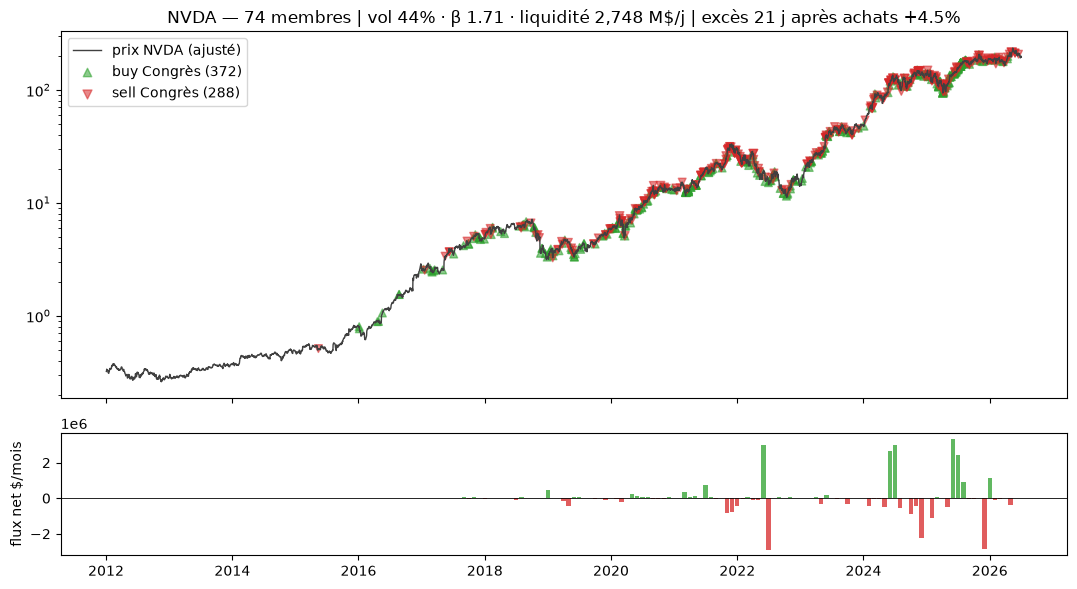

In [52]:
_pxd = (pd.read_csv(os.path.join(PRICES, TICKER_DEMO + ".csv"), parse_dates=["Date"])
          .set_index("Date")["close"].sort_index().dropna())
_gt = dfx[dfx.ticker == TICKER_DEMO]
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(_pxd, color="0.25", lw=1.0, label=f"prix {TICKER_DEMO} (ajusté)")
for _dop, _dc, _dmk in [("buy", C_BUY, "^"), ("sell", C_SELL, "v")]:
    _ds = _gt[_gt.op == _dop]
    _dy = _pxd.reindex(pd.DatetimeIndex(_ds["traded"]), method="ffill")
    ax[0].scatter(_ds["traded"], _dy.values, s=(np.log10(_ds["size_usd"].clip(lower=10)) * 8),
                  color=_dc, marker=_dmk, alpha=.55, label=f"{_dop} Congrès ({len(_ds):,})")
ax[0].set_yscale("log"); ax[0].legend(loc="upper left")
_rk = K.loc[TICKER_DEMO]
ax[0].set_title(f"{TICKER_DEMO} — {int(_rk['n_membres'])} membres | vol {_rk['vol_ann']:.0%} · β {_rk['beta_spy']:.2f} · "
                f"liquidité {_rk['adv_med']/1e6:,.0f} M$/j | excès 21 j après achats {_rk['exces_21j_moy']:+.1%}")
_flux = (_gt.assign(sgn=np.where(_gt.op == "buy", 1.0, -1.0) * _gt["size_usd"])
         .groupby(_gt["traded"].dt.to_period("M"))["sgn"].sum())
ax[1].bar(_flux.index.to_timestamp(), _flux.values, width=25,
          color=[C_BUY if v > 0 else C_SELL for v in _flux.values], alpha=.75)
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_ylabel("flux net $/mois")
plt.tight_layout(); plt.show()

## §12 `membres_annees` — le panel (membre, année civile)

**But** : l'activité et la performance de chaque membre, année par année.

L'activité vient des trades de l'année ; la performance vient de la tranche annuelle de $r_m$
(NaN sous 40 jours actifs dans l'année : trop peu pour annualiser — seuil anti-bruit) :

$$\texttt{ret\_annee}_{m,Y} = \prod_{t \in Y}(1 + r_m(t)) - 1, \qquad
\texttt{exces\_spy\_annee}_{m,Y} = \texttt{ret\_annee}_{m,Y} - \Big[\prod_{t \in Y}(1 + r_{SPY}(t)) - 1\Big]
\;\;(\text{mêmes jours})$$

In [53]:
_pa = dfx.assign(annee=dfx["traded"].dt.year).groupby(["bioguide_id", "annee"])
PAN = pd.DataFrame({
    "n_trades": _pa.size(),
    "n_buy": _pa["op"].agg(lambda s: int((s == "buy").sum())),
    "buy_share": _pa["op"].agg(lambda s: (s == "buy").mean()),
    "notional": _pa["size_usd"].sum(),
    "n_tickers": _pa["ticker"].nunique(),
    "sect_dom": _pa["sector_gics"].agg(_mode),
})
_rowsy = {}
for b, r in wf_ret.items():
    for Y, ry in r.groupby(r.index.year):
        rs = r_spy.reindex(ry.index).fillna(0.0)
        _rowsy[(b, Y)] = dict(
            n_days=len(ry),
            vol=float(ry.std() * np.sqrt(252)) if len(ry) >= 40 else np.nan,
            sharpe=float(ry.mean() / ry.std() * np.sqrt(252)) if (len(ry) >= 40 and ry.std() > 0) else np.nan,
            ret_annee=float((1 + ry).prod() - 1) if len(ry) >= 40 else np.nan,
            exces_spy_annee=float((1 + ry).prod() - (1 + rs).prod()) if len(ry) >= 40 else np.nan)
_pf = pd.DataFrame(_rowsy).T
_pf.index = pd.MultiIndex.from_tuples(_pf.index, names=["bioguide_id", "annee"])
PAN = PAN.join(_pf, how="outer")
PAN.index.names = ["bioguide_id", "annee"]
print(f"panel : {len(PAN)} lignes (membre, année) | avec performance annuelle : {int(PAN.ret_annee.notna().sum())}")

panel : 2628 lignes (membre, année) | avec performance annuelle : 2398


### §12.1 Contrôles

**Méthodes** : recoupement — la somme du panel doit redonner les totaux par membre ; recalcul à la
main d'une (membre, année).

In [54]:
assert int(PAN["n_trades"].fillna(0).sum()) == 118316
assert PAN.index.is_unique
# recoupement panel ↔ table membres : sommes par membre identiques
_par_m = PAN.groupby("bioguide_id")["n_trades"].sum()
assert (abs(_par_m - M["n_trades"].reindex(_par_m.index).fillna(0)) < 1e-9).all()
# recalcul à la main : le rendement annuel d'un membre = produit direct de sa série
_bp = M[M.eligible].sort_values("n_days", ascending=False).index[0]
_rp = wf_ret[_bp]
_Y = int(_rp.index.year[len(_rp) // 2])                      # une année au milieu de sa fenêtre
_ry = _rp[_rp.index.year == _Y]
assert abs(float((1 + _ry).prod() - 1) - PAN.loc[(_bp, _Y), "ret_annee"]) < 1e-12
print(f"§12.1 OK — Σ trades = 118 316 | recoupement panel↔membres exact | "
      f"recalcul direct identique sur {M.loc[_bp, 'name']} / {_Y}")

§12.1 OK — Σ trades = 118 316 | recoupement panel↔membres exact | recalcul direct identique sur Tammy Duckworth / 2019


**Aperçu** — le panel, sur les 8 (membre, année) aux plus gros notionals :

In [55]:
(PAN.join(M["name"], on="bioguide_id").sort_values("notional", ascending=False)
  [["name", "n_trades", "n_buy", "buy_share", "notional", "n_tickers", "sect_dom",
    "vol", "sharpe", "ret_annee", "exces_spy_annee"]]
  .head(8).round(3))

name  n_trades   n_buy  buy_share  \
bioguide_id annee                                                   
H001086     2021   Diana Harshbarger    1466.0   612.0      0.417   
K000389     2021        Rohit Khanna    2839.0  1804.0      0.635   
H001086     2022   Diana Harshbarger    1007.0   367.0      0.364   
L000594     2020      Kelly Loeffler     209.0    43.0      0.206   
B001135     2015      RICHARD M BURR      84.0    42.0      0.500   
M001157     2018   Michael T. McCaul    2392.0  1154.0      0.482   
            2021   Michael T. McCaul    1185.0   441.0      0.372   
            2020   Michael T. McCaul    1466.0   844.0      0.576   

                      notional  n_tickers                sect_dom    vol  \
bioguide_id annee                                                          
H001086     2021   242509849.0      132.0  Information Technology  0.200   
K000389     2021   161603419.0      587.0              Financials  0.141   
H001086     2022   136522567.5      121.0  Information Technology  0.214   
L000594     2020   113850104.5       89.0              Financials  0.453   
B001135     2015   112439041.5       24.0              Financials  0.159   
M001157     2018    94940196.0      193.0             Industrials  0.173   
            2021    91725593.0      159.0              Financials  0.149   
            2020    87074238.5      200.0             Industrials  0.361   

                   sharpe  ret_annee  exces_spy_annee  
bioguide_id annee                                      
H001086     2021    1.033      0.205           -0.082  
K000389     2021    1.733      0.264           -0.024  
H001086     2022   -0.290     -0.081            0.101  
L000594     2020    0.823      0.270            0.140  
B001135     2015    0.115      0.006           -0.007  
M001157     2018   -0.709     -0.128           -0.082  
            2021    1.466      0.230           -0.057  
            2020    0.516      0.129           -0.055

### §12.2 Démo — l'année par année du membre

**Lecture :** son rendement par année civile (bleu) contre le SPY sur les mêmes jours (gris) ;
le tableau donne le détail annuel (NaN quand moins de 40 jours actifs dans l'année).

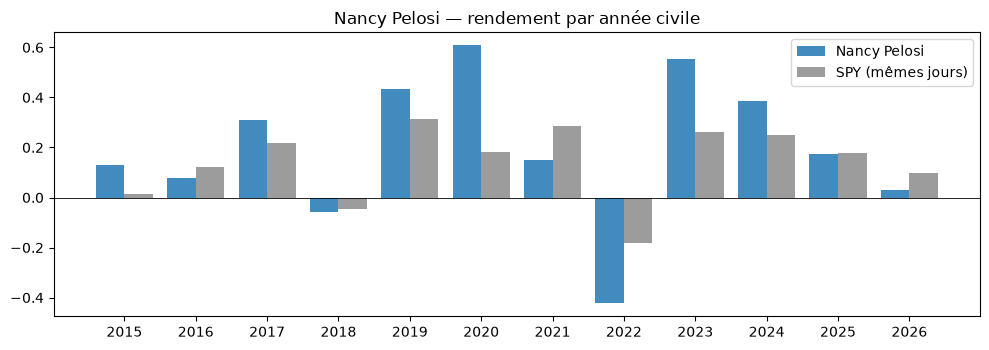

,n_trades,notional,n_tickers,vol,sharpe,ret_annee,exces_spy_annee
annee,,,,,,,
2014,20.0,1762010.0,9.0,NaN,NaN,NaN,NaN
2015,5.0,832502.5,3.0,0.226,0.652,0.129,0.117
2016,6.0,1758003.0,5.0,0.159,0.561,0.080,-0.040
2017,10.0,6390505.0,4.0,0.125,2.249,0.311,0.094
2018,11.0,7350005.5,5.0,0.270,-0.090,-0.059,-0.013
2019,4.0,533002.0,2.0,0.187,2.015,0.432,0.120
2020,21.0,26600010.5,12.0,0.367,1.476,0.609,0.425
2021,8.0,12750004.0,5.0,0.194,0.821,0.150,-0.137
2022,24.0,37675012.0,11.0,0.365,-1.330,-0.423,-0.242


In [56]:
_pm = PAN.loc[DEMO_BID].dropna(subset=["ret_annee"])
fig, ax = plt.subplots(figsize=(10, 3.6))
_ys = _pm.index.astype(int)
ax.bar(_ys - 0.2, _pm["ret_annee"].values, 0.4, color=C_M, alpha=.85, label=DEMO_NOM)
ax.bar(_ys + 0.2, [_pm.loc[y, "ret_annee"] - _pm.loc[y, "exces_spy_annee"] for y in _pm.index],
       0.4, color=C_SPY, alpha=.7, label="SPY (mêmes jours)")
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(_ys); ax.legend()
ax.set_title(f"{DEMO_NOM} — rendement par année civile")
plt.tight_layout(); plt.show()
display(PAN.loc[DEMO_BID][["n_trades", "notional", "n_tickers", "vol", "sharpe", "ret_annee", "exces_spy_annee"]].round(3))

## §13 Contrôles croisés entre les tables

Les tables `membres`, `tickers` et le panel décrivent la même donnée sous trois angles : toutes
les sommes doivent se recouper **exactement** (trades, montants, paires membre-ticker, bornes de
dates). Aucun CSV n'est écrit si un seul contrôle échoue.

In [57]:
# 1. sommes de trades identiques entre les deux tables et le périmètre
assert int(M["n_trades"].fillna(0).sum()) == int(K["n_trades"].fillna(0).sum()) == 118316
assert int(M["n_trades_brut"].sum()) == int(K["n_trades_brut"].sum()) == 134417
# 2. notionals au centime
assert abs(M["notional_buy"].fillna(0).sum() - K["notional_buy"].fillna(0).sum()) < 0.01
assert abs(M["notional_sell"].fillna(0).sum() - K["notional_sell"].fillna(0).sum()) < 0.01
# 3. bipartite : Σ_k n_membres = # paires (membre, ticker) distinctes = Σ_m n_tickers
_paires_mk = dfx.groupby(["bioguide_id", "ticker"]).ngroups
assert int(K["n_membres"].fillna(0).sum()) == _paires_mk == int(M["n_tickers"].fillna(0).sum())
# 4. bornes temporelles cohérentes
assert M["first_trade"].dropna().min() == K["first_trade"].dropna().min()
assert M["last_trade"].dropna().max() == K["last_trade"].dropna().max()
# 5. compteurs de population (l'entonnoir du §0.1)
assert len(M) == 372 and int(M["n_trades"].notna().sum()) == 359
assert int(M["reconstruit"].sum()) == 266 and int(M["eligible"].sum()) == 223
assert len(K) == 4607 and int(K["px_couvert"].sum()) == 3286
# 6. taux d'alignement comité identique vu des deux tables (pondéré par le nombre d'achats)
#    et égal à la moyenne calculée directement sur les trades
_ci_m = (M["part_ci_achats"] * M["n_buy"]).sum() / M["n_buy"].sum()
_ci_k = (K["part_ci_achats"] * K["n_buy"]).sum() / K["n_buy"].sum()
_ci_pool = dfx.loc[dfx.op == "buy", "ci"].mean()
assert abs(_ci_m - _ci_k) < 1e-12 and abs(_ci_m - _ci_pool) < 1e-12
# 7. épisodes de détention : la somme par membre = le total direct
assert int(M["n_episodes_fermes"].fillna(0).sum()) == len(_cl)
# 8. cohérences internes
assert int((M["n_buy"].fillna(0) + M["n_sell"].fillna(0)).sum()) == 118316
assert not M["name"].astype(str).str.contains(r"\|").any()
assert not pd.Index(K.index.astype(str)).str.contains(r"\|").any()
print("§13 OK — les 8 contrôles croisés passent : les trois tables racontent la même donnée")

§13 OK — les 8 contrôles croisés passent : les trois tables racontent la même donnée


## §14 Écriture des CSV et dictionnaire des colonnes

Le dictionnaire est la carte de lecture : une ligne par colonne (table, famille = la section qui
la construit, définition, source, type). Un `assert` garantit qu'il couvre exactement les
colonnes réellement écrites — aucune colonne non documentée ne peut sortir.

In [58]:
TABLES = os.path.join(BASE, "tables")
os.makedirs(TABLES, exist_ok=True)

D = []   # (table, famille, colonne, définition, source, type)
def _d(table, fam, col, definition, source, typ):
    D.append(dict(table=table, famille=fam, colonne=col, definition=definition, source=source, type=typ))

# ---- membres : identité (§2) ----
for c, dfn, src, ty in [
    ("name", "mode des variantes de nom", "§2", "str"),
    ("party", "mode sur les trades", "§2", "str"),
    ("chamber", "mode sur les trades (un House→Senate a un mode arbitraire)", "§2", "str"),
    ("state", "state_district[:2]", "§2", "str"),
    ("congress_first", "n° du premier Congrès tradé (mandat de 2 ans ; 113e = 2013-2014)", "§2", "int"),
    ("congress_last", "n° du dernier Congrès tradé", "§2", "int"),
    ("years_in_office", "ancienneté (années de mandat)", "anciennete_2014_2026.csv", "float"),
    ("leader", "occupe l'un des 12 postes de direction des partis", "leadership_2014_2026.csv", "bool"),
    ("leader_postes", "postes occupés, séparés par |", "leadership_2014_2026.csv", "str"),
    ("comites", "∪ codes THOMAS racine (4 lettres), séparés par |", "§2", "str"),
    ("comite_cle", "∃ trade avec committees_key_flag", "§2", "bool"),
    ("secteurs_juridiction", "∪ secteurs GICS supervisés par ses comités, séparés par |", "matrice §1", "str"),
    ("n_secteurs_juridiction", "cardinal de secteurs_juridiction", "§2", "int")]:
    _d("membres", "identite (§2)", c, dfn, src, ty)
# ---- membres : activité (§3) ----
for c, dfn, src, ty in [
    ("n_trades_brut", "# trades dans 𝒯^brut (134 417)", "§3", "int"),
    ("n_trades", "# trades dans 𝒯 (118 316)", "§3", "int"),
    ("n_buy", "# achats", "§3", "int"), ("n_sell", "# ventes", "§3", "int"),
    ("buy_share", "n_buy / n_trades", "§3", "float"),
    ("notional_total", "Σ A_j (milieux de fourchettes)", "§3", "float"),
    ("notional_buy", "Σ A_j achats", "§3", "float"), ("notional_sell", "Σ A_j ventes", "§3", "float"),
    ("taille_med", "med(A_j)", "§3", "float"),
    ("pct_1re_fourchette", "P(A_j ≤ 8 000,5) — la plus petite fourchette légale", "§3", "float"),
    ("lag_med", "med(δ_j − τ_j) : délai médian de déclaration, en jours", "§3", "float"),
    ("part_late", "P(lag > 45 j) — au-delà du délai légal", "§3", "float"),
    ("part_very_late", "P(lag > 365 j)", "§3", "float"),
    ("owner_dom", "mode(owner : élu/conjoint/joint/enfant)", "§3", "str"),
    ("part_conjoint", "P(owner = conjoint)", "§3", "float"),
    ("part_self", "P(owner = élu)", "§3", "float"),
    ("first_trade", "min(τ_j)", "§3", "date"), ("last_trade", "max(τ_j)", "§3", "date"),
    ("duree_activite_j", "(last − first) en jours", "§3", "int"),
    ("n_annees_actives", "# années avec ≥1 trade", "§3", "int"),
    ("actif_12m", "last_trade ≥ max(cal) − 365 j", "§3", "bool")]:
    _d("membres", "activite (§3)", c, dfn, src, ty)
# ---- membres : portefeuille (§4) ----
for c, dfn, src, ty in [
    ("reconstruit", "série r_m calculable", "moteur §1", "bool"),
    ("n_days", "T_m = # jours actifs", "moteur §1", "int"),
    ("n_tickers", "# tickers distincts", "§4", "int"),
    ("valeur_moy", "V̄_m sur jours actifs", "§4", "float"),
    ("valeur_fin", "V_m(dernier jour)", "§4", "float"),
    ("hhi", "concentration : moyenne_t Σ_k w²", "§4", "float"),
    ("n_eff", "1/HHI : nombre équivalent de lignes équipondérées", "§4", "float"),
    ("top1", "poids moyen de la plus grosse ligne", "§4", "float"),
    ("n_pos_moy", "# positions ouvertes moyen", "§4", "float"),
    ("turnover", "rotation : ΣA_j / (2 V̄) · 252/T", "§4", "float"),
    ("n_episodes_fermes", "# épisodes achat→revente clos (FIFO)", "§4", "int")]:
    _d("membres", "portefeuille (§4)", c, dfn, src, ty)
# ---- membres : durées (§5) ----
for c, dfn, src, ty in [
    ("duree_med_fermee", "médiane pondérée-parts des durées closes (j)", "§5", "float"),
    ("duree_km_med", "durée médiane de détention, Kaplan-Meier (NaN si >50 % jamais revendu)", "§5", "float"),
    ("part_ouverte", "parts encore détenues / parts totales", "§5", "float"),
    ("n_allers_retours_30j", "# épisodes clos < 30 j", "§5", "int")]:
    _d("membres", "durees (§5)", c, dfn, src, ty)
# ---- membres : actions & secteurs (§6) ----
for c, dfn, src, ty in [
    ("top1_ticker", "1er ticker par notional d'achat", "§6", "str"),
    ("top1_part", "sa part du notional d'achat", "§6", "float"),
    ("top2_ticker", "2e ticker", "§6", "str"), ("top2_part", "sa part", "§6", "float"),
    ("top3_ticker", "3e ticker", "§6", "str"), ("top3_part", "sa part", "§6", "float"),
    ("top10_tickers", "top-10 tickers par notional d'achat, séparés par |", "§6", "str"),
    ("sect_dom", "secteur GICS le plus fréquent des achats", "§6", "str"),
    ("part_sect_dom", "part du notional d'achat du secteur dominant", "§6", "float")]:
    _d("membres", "actions_secteurs (§6)", c, dfn, src, ty)
_SECT_DEF = {"sect_info_tech": "Information Technology", "sect_financials": "Financials",
             "sect_health": "Health Care", "sect_industrials": "Industrials",
             "sect_conso_disc": "Consumer Discretionary", "sect_comm": "Communication Services",
             "sect_conso_stap": "Consumer Staples", "sect_energy": "Energy",
             "sect_materials": "Materials", "sect_real_estate": "Real Estate",
             "sect_utilities": "Utilities", "sect_nc": "secteur GICS manquant"}
for c, lib in _SECT_DEF.items():
    _d("membres", "actions_secteurs (§6)", c, f"part du notional d'achat en {lib} (Σ des 12 = 1)", "§6", "float")
# ---- membres : risque/perf (§7) ----
for c, dfn, src, ty in [
    ("cagr", "croissance annualisée : NAV^(252/T) − 1", "§7", "float"),
    ("vol", "volatilité annualisée : σ(r_m)·√252", "§7", "float"),
    ("sharpe", "rendement par unité de risque : r̄/σ·√252", "§7", "float"),
    ("sortino", "comme le Sharpe, seule la vol de baisse pénalise : r̄/σ(r⁻)·√252", "§7", "float"),
    ("maxdd", "pire perte depuis un sommet : min(NAV/cummax − 1)", "§7", "float"),
    ("t_sharpe", "t de Student du Sharpe : sharpe·√(T/252)", "§7", "float"),
    ("ir", "information ratio vs SPY", "§7", "float"),
    ("t_ir", "t de Student de l'IR : IR·√(T/252)", "§7", "float"),
    ("beta", "sensibilité au marché : pente de la régression r_m ~ r_SPY", "§7", "float"),
    ("alpha_ann", "reste annualisé une fois l'effet marché retiré : (1+α)^252 − 1", "§7", "float"),
    ("appraisal", "alpha / risque résiduel : α/σ_ε·√252", "§7", "float"),
    ("t_appr", "t de Student de l'appraisal : appraisal·√(T/252)", "§7", "float"),
    ("exces_cagr_spy", "CAGR_m − CAGR_SPY (même fenêtre)", "§7", "float"),
    ("eligible", "n_trades ≥ 10 et T ≥ 126 j (seuils du §0.1)", "§7", "bool")]:
    _d("membres", "risque_perf (§7)", c, dfn, src, ty)
# ---- membres : track record (§8) ----
for c, dfn, src, ty in [
    ("n_trades_evalues", "# achats avec x_j calculable", "§8", "int"),
    ("hit_rate", "P(x_j > 0) : part des achats qui battent le marché", "§8", "float"),
    ("exces_moyen_trade", "moyenne des x_j", "§8", "float"),
    ("exces_med_trade", "med(x_j)", "§8", "float"),
    ("ret_brut_moyen_trade", "moyenne des rendements bruts par achat", "§8", "float"),
    ("profit_factor", "Σ excès gagnés / Σ excès perdus, plafonné à 10", "§8", "float"),
    ("t_exces_trade", "t de Student de l'excès moyen : x̄/(σ_x/√n)", "§8", "float")]:
    _d("membres", "track_record (§8)", c, dfn, src, ty)
# ---- membres : comportement (§9) ----
for c, dfn, src, ty in [
    ("part_ci_achats", "P(secteur du titre ∈ juridiction des comités du membre | achat)", "§9", "float"),
    ("part_trades_repetes", "P(ticker déjà tradé avant par le membre)", "§9", "float"),
    ("part_coachat", "P(achat dans un (ticker, mois) à ≥3 acheteurs)", "§9", "float")]:
    _d("membres", "comportement (§9)", c, dfn, src, ty)

# ---- tickers ----
for c, dfn, src, ty in [
    ("description", "mode(asset_description), 80 caractères", "§10", "str"),
    ("asset_class", "mode (action / ETF)", "§10", "str"), ("is_broad_etf", "ETF large (type S&P 500)", "§10", "bool"),
    ("sector_gics", "mode", "§10", "str"), ("etf_proxy", "mode (ETF sectoriel correspondant)", "§10", "str"),
    ("is_delisted", "titre sorti de la cote", "§10", "bool"), ("delist_type", "mode (rachat/faillite/recyclage)", "§10", "str"),
    ("flag_price_caution", "série de prix à manier avec prudence", "§10", "bool")]:
    _d("tickers", "identite (§10)", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("n_trades_brut", "# trades 𝒯^brut", "§10", "int"), ("n_trades", "# trades 𝒯", "§10", "int"),
    ("n_buy", "# achats", "§10", "int"), ("n_sell", "# ventes", "§10", "int"),
    ("notional_buy", "Σ A_j achats", "§10", "float"), ("notional_sell", "Σ A_j ventes", "§10", "float"),
    ("notional_net", "achats − ventes, en $", "§10", "float"),
    ("n_membres", "# membres distincts", "§10", "int"),
    ("n_membres_buy", "# acheteurs distincts", "§10", "int"),
    ("n_membres_sell", "# vendeurs distincts", "§10", "int"),
    ("part_dem", "part du notional d'achat venant de Démocrates", "§10", "float"),
    ("part_senate", "part des trades venant du Sénat", "§10", "float"),
    ("part_conjoint", "part des trades owner = conjoint", "§10", "float"),
    ("part_ci_achats", "part des achats alignés comité×secteur", "§10", "float"),
    ("first_trade", "min(τ_j)", "§10", "date"), ("last_trade", "max(τ_j)", "§10", "date"),
    ("n_mois_actifs", "# (année, mois) avec ≥1 trade", "§10", "int"),
    ("coachat_max", "record mensuel d'acheteurs distincts", "§10", "int"),
    ("top_membres", "top-3 bioguide_id par notional, séparés par |", "§10", "str")]:
    _d("tickers", "flux_congres (§10)", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("px_couvert", "ticker avec série de prix exploitable", "§11", "bool"),
    ("px_first", "1re cotation observée", "§11", "date"),
    ("px_last", "dernière cotation observée", "§11", "date"),
    ("px_n_obs", "# jours cotés", "§11", "int"),
    ("adv_med", "volume d'échanges médian, $/jour (liquidité)", "§11", "float"),
    ("vol_ann", "volatilité annualisée du titre", "§11", "float"),
    ("beta_spy", "sensibilité au marché (≥126 jours communs)", "§11", "float"),
    ("cagr_fenetre", "croissance annualisée sur la fenêtre observée", "§11", "float"),
    ("maxdd", "pire perte depuis un sommet", "§11", "float"),
    ("ret_total", "rendement total sur la fenêtre observée", "§11", "float")]:
    _d("tickers", "marche (§11)", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("exces_21j_moy", "excès moyen vs SPY à 21 j après les achats du Congrès", "§11", "float"),
    ("exces_63j_moy", "idem à 63 j", "§11", "float"),
    ("n_achats_evalues", "# achats avec fenêtre 21 j complète", "§11", "int")]:
    _d("tickers", "apres_achats (§11)", c, dfn, src, ty)

# ---- panel ----
for c, dfn, src, ty in [
    ("n_trades", "# trades de l'année", "§12", "int"), ("n_buy", "# achats", "§12", "int"),
    ("buy_share", "part d'achats", "§12", "float"), ("notional", "Σ A_j", "§12", "float"),
    ("n_tickers", "# tickers distincts", "§12", "int"), ("sect_dom", "mode GICS", "§12", "str"),
    ("n_days", "# jours actifs de r_m dans l'année", "§12", "int"),
    ("vol", "σ(r_m)·√252 (NaN si <40 j)", "§12", "float"),
    ("sharpe", "r̄/σ·√252 (NaN si <40 j)", "§12", "float"),
    ("ret_annee", "Π(1+r_m) − 1 (NaN si <40 j)", "§12", "float"),
    ("exces_spy_annee", "ret_annee − ret_SPY (mêmes jours)", "§12", "float")]:
    _d("membres_annees", "panel (§12)", c, dfn, src, ty)

DICO = pd.DataFrame(D)
# le dictionnaire couvre EXACTEMENT les colonnes écrites
assert set(DICO[DICO.table == "membres"].colonne) == set(M.columns), \
    (set(DICO[DICO.table == "membres"].colonne) ^ set(M.columns))
assert set(DICO[DICO.table == "tickers"].colonne) == set(K.columns), \
    (set(DICO[DICO.table == "tickers"].colonne) ^ set(K.columns))
assert set(DICO[DICO.table == "membres_annees"].colonne) == set(PAN.columns), \
    (set(DICO[DICO.table == "membres_annees"].colonne) ^ set(PAN.columns))

M.to_csv(os.path.join(TABLES, "membres.csv"))
K.to_csv(os.path.join(TABLES, "tickers.csv"))
PAN.to_csv(os.path.join(TABLES, "membres_annees.csv"))
DICO.to_csv(os.path.join(TABLES, "dictionnaire_colonnes.csv"), index=False)
print(f"écrit dans {TABLES} :")
print(f"  membres.csv          {M.shape[0]} × {M.shape[1]}")
print(f"  tickers.csv          {K.shape[0]} × {K.shape[1]}")
print(f"  membres_annees.csv   {PAN.shape[0]} × {PAN.shape[1]}")
print(f"  dictionnaire_colonnes.csv  {len(DICO)} colonnes documentées")

écrit dans /Users/lemairealice/Downloads/Jupiter/02_recherche_backtest/tables :
  membres.csv          372 × 94
  tickers.csv          4607 × 40
  membres_annees.csv   2628 × 11
  dictionnaire_colonnes.csv  145 colonnes documentées


### §14.1 Le dictionnaire complet — la carte de lecture des 3 fichiers

Chaque colonne de chaque CSV : sa définition, la section qui la calcule, son type.

In [59]:
pd.set_option("display.max_rows", 200)
DICO[DICO.table == "membres"].drop(columns="table").reset_index(drop=True)

,famille,colonne,definition,source,type
0,identite (§2),name,mode des variantes de nom,§2,str
1,identite (§2),party,mode sur les trades,§2,str
2,identite (§2),chamber,mode sur les trades (un House→Senate a un mode...,§2,str
3,identite (§2),state,state_district[:2],§2,str
4,identite (§2),congress_first,n° du premier Congrès tradé (mandat de 2 ans ;...,§2,int
5,identite (§2),congress_last,n° du dernier Congrès tradé,§2,int
6,identite (§2),years_in_office,ancienneté (années de mandat),anciennete_2014_2026.csv,float
7,identite (§2),leader,occupe l'un des 12 postes de direction des partis,leadership_2014_2026.csv,bool
8,identite (§2),leader_postes,"postes occupés, séparés par |",leadership_2014_2026.csv,str
9,identite (§2),comites,"∪ codes THOMAS racine (4 lettres), séparés par |",§2,str


In [60]:
DICO[DICO.table == "tickers"].drop(columns="table").reset_index(drop=True)

,famille,colonne,definition,source,type
0,identite (§10),description,"mode(asset_description), 80 caractères",§10,str
1,identite (§10),asset_class,mode (action / ETF),§10,str
2,identite (§10),is_broad_etf,ETF large (type S&P 500),§10,bool
3,identite (§10),sector_gics,mode,§10,str
4,identite (§10),etf_proxy,mode (ETF sectoriel correspondant),§10,str
5,identite (§10),is_delisted,titre sorti de la cote,§10,bool
6,identite (§10),delist_type,mode (rachat/faillite/recyclage),§10,str
7,identite (§10),flag_price_caution,série de prix à manier avec prudence,§10,bool
8,flux_congres (§10),n_trades_brut,# trades 𝒯^brut,§10,int
9,flux_congres (§10),n_trades,# trades 𝒯,§10,int


In [61]:
DICO[DICO.table == "membres_annees"].drop(columns="table").reset_index(drop=True)

,famille,colonne,definition,source,type
0,panel (§12),n_trades,# trades de l'année,§12,int
1,panel (§12),n_buy,# achats,§12,int
2,panel (§12),buy_share,part d'achats,§12,float
3,panel (§12),notional,Σ A_j,§12,float
4,panel (§12),n_tickers,# tickers distincts,§12,int
5,panel (§12),sect_dom,mode GICS,§12,str
6,panel (§12),n_days,# jours actifs de r_m dans l'année,§12,int
7,panel (§12),vol,σ(r_m)·√252 (NaN si <40 j),§12,float
8,panel (§12),sharpe,r̄/σ·√252 (NaN si <40 j),§12,float
9,panel (§12),ret_annee,Π(1+r_m) − 1 (NaN si <40 j),§12,float


### §14.2 Trois distributions pour prendre les tables en main

De gauche à droite : la volatilité des 223 membres éligibles (à quel point leurs portefeuilles
bougent) ; la durée médiane de détention (Kaplan-Meier, quand elle existe) ; le notional d'achat
par ticker (échelle log : la plupart des titres reçoivent peu, quelques-uns énormément).

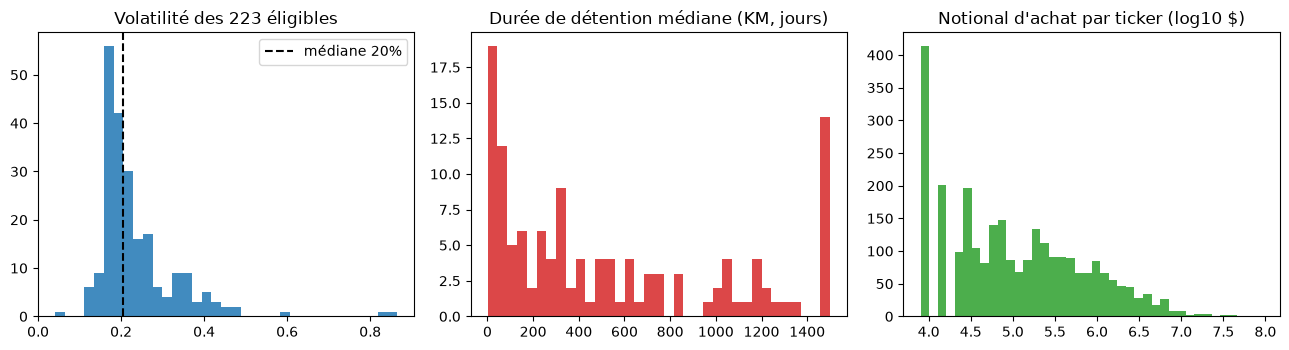

Les tables sont prêtes : membres.csv / tickers.csv / membres_annees.csv + dictionnaire_colonnes.csv


In [62]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
_e = M[M.eligible]
ax[0].hist(_e["vol"].dropna().clip(upper=1.0), bins=35, color="tab:blue", alpha=.85)
ax[0].axvline(float(_e["vol"].median()), color="k", ls="--", label=f"médiane {_e['vol'].median():.0%}")
ax[0].set_title("Volatilité des 223 éligibles"); ax[0].legend()
ax[1].hist(M["duree_km_med"].dropna().clip(upper=1500), bins=35, color="tab:red", alpha=.85)
ax[1].set_title("Durée de détention médiane (KM, jours)")
ax[2].hist(np.log10(K["notional_buy"].dropna().clip(lower=1)), bins=40, color="tab:green", alpha=.85)
ax[2].set_title("Notional d'achat par ticker (log10 $)")
plt.tight_layout(); plt.show()
print("Les tables sont prêtes : membres.csv / tickers.csv / membres_annees.csv + dictionnaire_colonnes.csv")